In [2]:
import json
import random
from pathlib import Path

# -----------------------------
# Configuration
# -----------------------------
INPUT_JSON = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json")
OUTPUT_JSON = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_filtered.json")

REMOVE_ONLY_2C = 0.90      # Remove 90%
REMOVE_EMPTY = 0.80         # Remove 80%

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# -----------------------------
# Load dataset
# -----------------------------
with open(INPUT_JSON, "r") as f:
    dataset = json.load(f)

filtered_dataset = {}

total_removed_only2c = 0
total_removed_empty = 0

# -----------------------------
# Process each split
# -----------------------------
for split, cases in dataset.items():

    if split != "train":
        filtered_dataset[split] = cases
        print(f"{split}: unchanged ({len(cases)} cases)")
        continue
    
    only_2c_indices = []
    empty_indices = []

    for idx, case in enumerate(cases):
        categories = case.get("categories", {})

        # Empty categories
        if len(categories) == 0:
            empty_indices.append(idx)

        # Only 2c categories
        elif all(cat == "2c" for cat in categories.values()):
            only_2c_indices.append(idx)

    # Randomly choose which ones to remove
    remove_only2c = set(
        random.sample(
            only_2c_indices,
            int(len(only_2c_indices) * REMOVE_ONLY_2C)
        )
    )

    remove_empty = set(
        random.sample(
            empty_indices,
            int(len(empty_indices) * REMOVE_EMPTY)
        )
    )

    remove_indices = remove_only2c | remove_empty

    filtered_cases = [
        case
        for idx, case in enumerate(cases)
        if idx not in remove_indices
    ]

    filtered_dataset[split] = filtered_cases

    print(f"\n{split}")
    print(f"  Only-2c cases : {len(only_2c_indices)}")
    print(f"  Removed       : {len(remove_only2c)}")
    print(f"  Remaining     : {len(only_2c_indices) - len(remove_only2c)}")

    print(f"  Empty cases   : {len(empty_indices)}")
    print(f"  Removed       : {len(remove_empty)}")
    print(f"  Remaining     : {len(empty_indices) - len(remove_empty)}")

    total_removed_only2c += len(remove_only2c)
    total_removed_empty += len(remove_empty)

# -----------------------------
# Save
# -----------------------------
with open(OUTPUT_JSON, "w") as f:
    json.dump(filtered_dataset, f, indent=4)

print("\n===================================")
print(f"Total removed (only 2c): {total_removed_only2c}")
print(f"Total removed (empty)  : {total_removed_empty}")
print(f"Saved filtered dataset to: {OUTPUT_JSON}")


train
  Only-2c cases : 708
  Removed       : 637
  Remaining     : 71
  Empty cases   : 347
  Removed       : 277
  Remaining     : 70
test: unchanged (583 cases)

Total removed (only 2c): 637
Total removed (empty)  : 277
Saved filtered dataset to: /home/chest_ct/code/data/rexgrounding-ct/dataset_2_filtered.json


CT shape: (1024, 1024, 114)


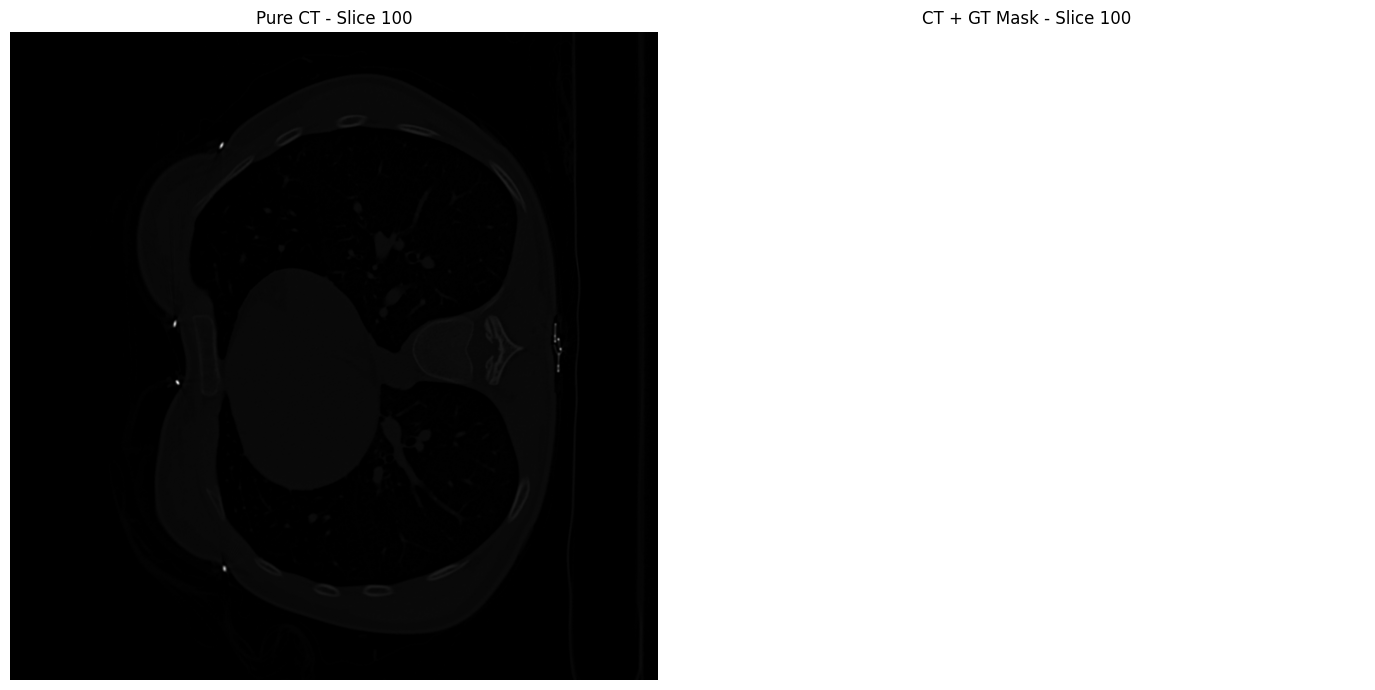

In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_13441_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()


print("CT shape:", ct.shape)


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, 50],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice 100")
axes[0].axis("off")


axes[1].set_title(f"CT + GT Mask - Slice 100")
axes[1].axis("off")


plt.tight_layout()
plt.show()

CT shape: (512, 512, 461)
GT mask shape: (1, 512, 512, 461)
GT labels: [0. 1. 2. 3.]
Using GT mask shape: (512, 512, 461)
Displaying slice: 333

Voxel counts
CT total voxels        : 120848384
Mask total voxels      : 120848384
Mask positive voxels   : 7253
Mask background voxels : 120841131
Mask percentage of CT  : 0.006002%


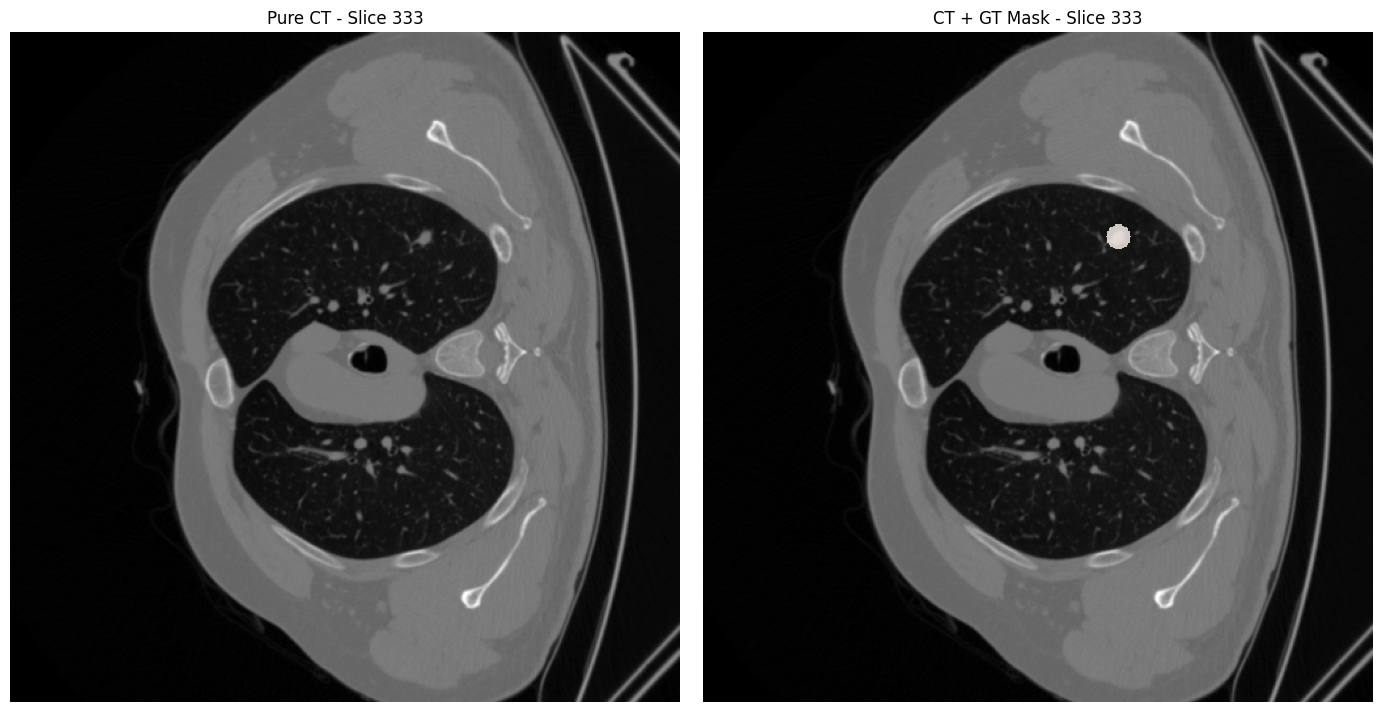

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\data_volumes\dataset\train_fixed\train_1387\train_1387_a\train_1387_a_2.nii.gz"

mask_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\segmentations\segmentations\train_1387_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()


print("CT shape:", ct.shape)
print("GT mask shape:", gt_mask.shape)
print("GT labels:", np.unique(gt_mask)[:20])


# -----------------------------
# Handle mask dimensions
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most nodule
# -----------------------------

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0, 1))
)

print("Displaying slice:", slice_idx)

# -----------------------------
# Voxel counts
# -----------------------------

ct_voxels = ct.size
mask_voxels = gt_mask.size

positive_mask_voxels = np.count_nonzero(gt_mask > 0)
zero_mask_voxels = mask_voxels - positive_mask_voxels

mask_percentage_of_volume = (positive_mask_voxels / ct_voxels) * 100

print("\nVoxel counts")
print("CT total voxels        :", ct_voxels)
print("Mask total voxels      :", mask_voxels)
print("Mask positive voxels   :", positive_mask_voxels)
print("Mask background voxels :", zero_mask_voxels)
print(f"Mask percentage of CT  : {mask_percentage_of_volume:.6f}%")


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice {slice_idx}")
axes[0].axis("off")


# CT + GT mask overlay
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

seg = gt_mask[:, :, slice_idx]

axes[1].imshow(
    np.ma.masked_where(
        seg <= 0,
        seg
    ),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[1].set_title(f"CT + GT Mask - Slice {slice_idx}")
axes[1].axis("off")


plt.tight_layout()
plt.show()

CT shape: (512, 512, 461)
GT shape: (1, 512, 512, 461)
GT labels: [0. 1. 2. 3.]
Loading Merlin...


/home/chest_ct/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chest_ct/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Merlin loaded on: cuda:0
Input tensor: torch.Size([1, 1, 128, 128, 231])
Downsampled shape: (128, 128, 231)
Original shape: (512, 512, 461)


/home/chest_ct/code/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


CAM shape: (128, 128, 231)
CAM range: 0.0 1.0
Resized CAM: (512, 512, 461)
GT voxels: 7253
CAM voxels: 58109744

===== Grad-CAM Evaluation =====
Dice      : 0.0002
IoU       : 0.0001
Precision : 0.0001
Recall    : 0.8266
Best slice: 333


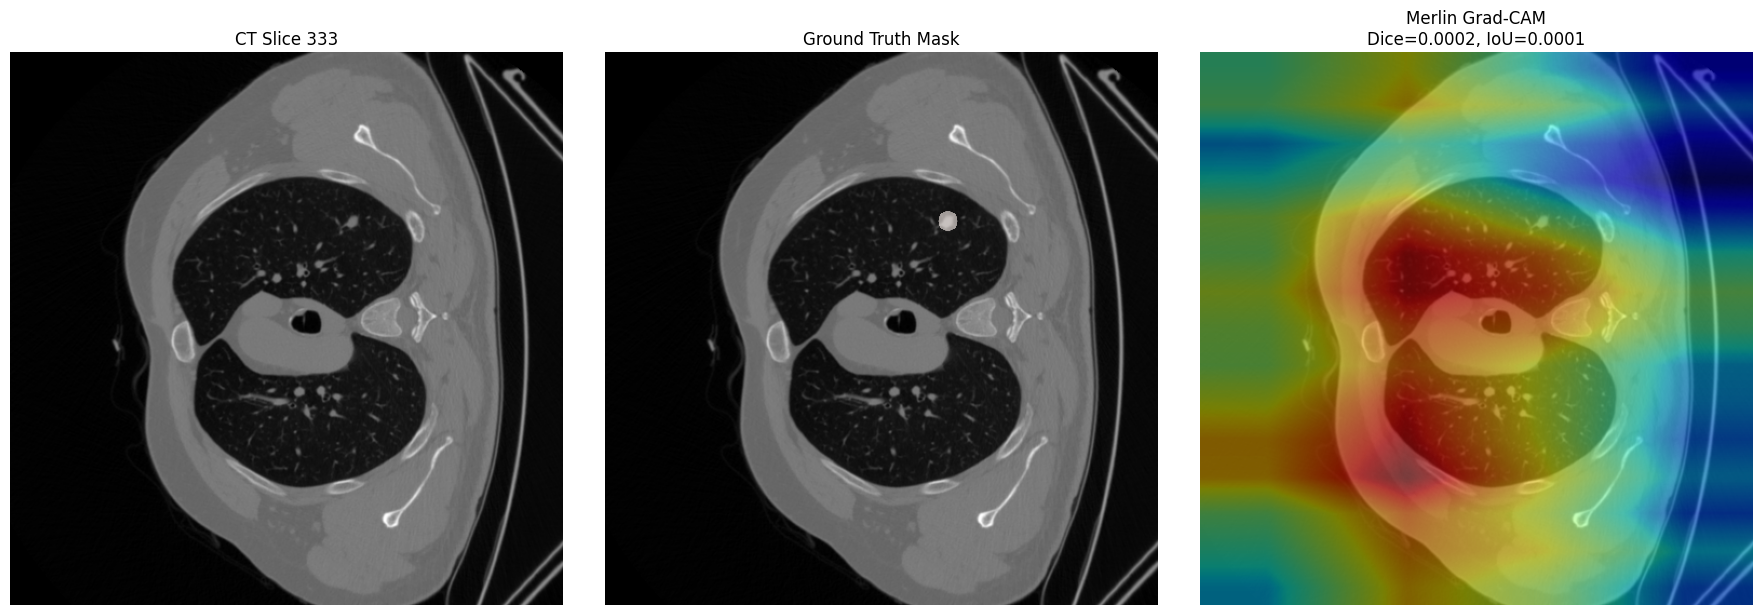

In [4]:
import os
import sys
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# Make the Merlin repo importable from this notebook.
sys.path.insert(0, "/home/chest_ct/code/models/merlin")


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path), "CT file not found"
assert os.path.exists(gt_path), "GT mask file not found"


# ============================================================
# Load CT + Ground Truth
# ============================================================

ct = nib.load(ct_path).get_fdata()
gt = nib.load(gt_path).get_fdata()


print("CT shape:", ct.shape)
print("GT shape:", gt.shape)
print("GT labels:", np.unique(gt))


# Handle 4D masks if present
if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0


# ============================================================
# Load Merlin + Grad-CAM helpers
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.inference.predict import MerlinPredictor
from explainability.gradcam.gradcam3d import GradCAM3D
from explainability.gradcam.target import ImageEmbeddingNormTarget


model, target_layer = load_merlin(image_embedding_only=True)
predictor = MerlinPredictor(model, image_embedding_only=True)

print("Merlin loaded on:", next(model.parameters()).device)


# ============================================================
# Preprocess CT
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(ct_path)

print("Input tensor:", image_tensor.shape)
print("Downsampled shape:", ds_shape)
print("Original shape:", original_shape)


# ============================================================
# Generate Grad-CAM
# ============================================================

cam_generator = GradCAM3D(model, target_layer, predictor.forward)

cam = cam_generator(
    image_tensor,
    ImageEmbeddingNormTarget(),
    output_size=ds_shape,
)
cam_generator.release()

cam = np.asarray(cam)

print("CAM shape:", cam.shape)
print(
    "CAM range:",
    cam.min(),
    cam.max()
)


# ============================================================
# Resize CAM to CT resolution
# ============================================================

resize_factor = (
    ct.shape[0] / cam.shape[0],
    ct.shape[1] / cam.shape[1],
    ct.shape[2] / cam.shape[2]
)


cam_full = zoom(
    cam,
    resize_factor,
    order=1
)


print("Resized CAM:", cam_full.shape)


# ============================================================
# Threshold CAM
# ============================================================

threshold = 0.5

cam_mask = cam_full > threshold


print(
    "GT voxels:",
    gt_mask.sum()
)

print(
    "CAM voxels:",
    cam_mask.sum()
)


# ============================================================
# Dice
# ============================================================

intersection = np.logical_and(
    cam_mask,
    gt_mask
).sum()


dice = (
    2 * intersection /
    (
        cam_mask.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


# ============================================================
# IoU
# ============================================================

union = np.logical_or(
    cam_mask,
    gt_mask
).sum()


iou = intersection / (union + 1e-8)



# ============================================================
# Precision / Recall
# ============================================================

tp = np.logical_and(
    cam_mask,
    gt_mask
).sum()


fp = np.logical_and(
    cam_mask,
    ~gt_mask
).sum()


fn = np.logical_and(
    ~cam_mask,
    gt_mask
).sum()


precision = tp / (tp + fp + 1e-8)

recall = tp / (tp + fn + 1e-8)



# ============================================================
# Print Metrics
# ============================================================

print("\n===== Grad-CAM Evaluation =====")

print(f"Dice      : {dice:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


print(
    "Best slice:",
    slice_idx
)


plt.figure(figsize=(18,6))


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT Slice {slice_idx}"
)

plt.axis("off")



# Ground Truth

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] == 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth Mask"
)

plt.axis("off")



# GradCAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Merlin Grad-CAM\nDice={dice:.4f}, IoU={iou:.4f}"
)

plt.axis("off")


plt.tight_layout()
plt.show()

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT labels: [0. 1. 2. 3.]
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Merlin device: cuda:0

Input tensor:
torch.Size([1, 1, 128, 128, 231])
Preprocess output shape:
(128, 128, 231)
Original shape:
(512, 512, 461)
CAM shape: (128, 128, 231)
CAM range: 0.0 1.0
Resized CAM: (512, 512, 461)

Shape verification
CT       : (512, 512, 461)
GT       : (512, 512, 461)
CAM full : (512, 512, 461)
CAM threshold: 0.7829854
GT voxels: 7253
CAM voxels: 6042424

Resized CAM:
(512, 512, 461)
GT shape: (512, 512, 461)
Saved CAM: train_1387_a_2_gradcam.nii.gz

Threshold:
0.7829854
GT voxels: 7253
CAM voxels: 6042424

Grad-CAM Evaluation
Dice      : 0.0000
IoU       : 0.0000
Precision : 0.0000
Recall    : 0.0000

Best slice: 333


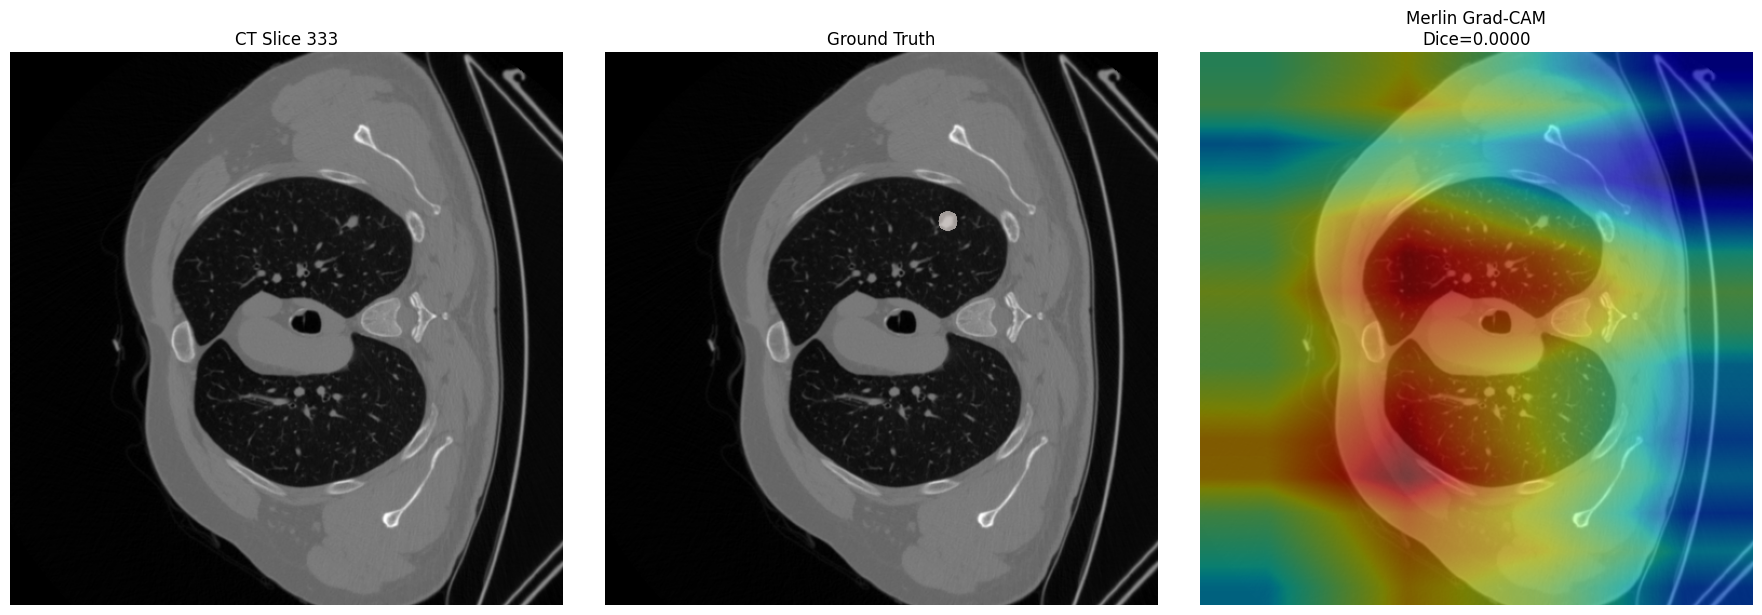

In [6]:
import os
import sys
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Make Merlin importable
# ============================================================

sys.path.insert(0, "/home/chest_ct/code/models/merlin")


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path), f"CT not found: {ct_path}"
assert os.path.exists(gt_path), f"GT not found: {gt_path}"


# ============================================================
# Load CT + Ground Truth
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()
gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0


print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT labels:", np.unique(gt))


# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.inference.predict import MerlinPredictor
from explainability.gradcam.gradcam3d import GradCAM3D
from explainability.gradcam.target import ImageEmbeddingNormTarget


model, target_layer = load_merlin(
    image_embedding_only=True
)

predictor = MerlinPredictor(
    model,
    image_embedding_only=True
)


device = next(model.parameters()).device

print("Merlin device:", device)


# ============================================================
# Preprocess CT
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)


print("\nInput tensor:")
print(image_tensor.shape)

print("Preprocess output shape:")
print(ds_shape)

print("Original shape:")
print(original_shape)



# ============================================================
# Generate Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    predictor.forward
)


cam = cam_generator(
    image_tensor,
    ImageEmbeddingNormTarget(),
    output_size=image_tensor.shape[2:]
)


cam_generator.release()


cam = np.asarray(cam)


print("CAM shape:", cam.shape)
print(
    "CAM range:",
    cam.min(),
    cam.max()
)



# ============================================================
# Resize CAM to CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0] / cam.shape[0],
        ct.shape[1] / cam.shape[1],
        ct.shape[2] / cam.shape[2]
    ),
    order=1
)


print("Resized CAM:", cam_full.shape)


print("\nShape verification")
print("CT       :", ct.shape)
print("GT       :", gt_mask.shape)
print("CAM full :", cam_full.shape)



# ============================================================
# Threshold CAM
# ============================================================

threshold = np.percentile(
    cam_full,
    95
)


cam_mask = cam_full >= threshold


print("CAM threshold:", threshold)

print(
    "GT voxels:",
    gt_mask.sum()
)

print(
    "CAM voxels:",
    cam_mask.sum()
)


# ============================================================
# Resize CAM to CT size
# ============================================================

resize_factor = (
    ct.shape[0] / cam.shape[0],
    ct.shape[1] / cam.shape[1],
    ct.shape[2] / cam.shape[2]
)


cam_full = zoom(
    cam,
    resize_factor,
    order=1
)


print("\nResized CAM:")
print(cam_full.shape)


print(
    "GT shape:",
    gt_mask.shape
)



# ============================================================
# Save CAM as NIfTI
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_gradcam.nii.gz"
)


print(
    "Saved CAM:"
    " train_1387_a_2_gradcam.nii.gz"
)



# ============================================================
# Threshold CAM
# ============================================================

threshold = np.percentile(
    cam_full,
    95
)


cam_mask = cam_full >= threshold


print("\nThreshold:")
print(threshold)


print(
    "GT voxels:",
    gt_mask.sum()
)


print(
    "CAM voxels:",
    cam_mask.sum()
)



# ============================================================
# Dice
# ============================================================

intersection = np.logical_and(
    cam_mask,
    gt_mask
).sum()


dice = (
    2 * intersection /
    (
        cam_mask.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)



# ============================================================
# IoU
# ============================================================

union = np.logical_or(
    cam_mask,
    gt_mask
).sum()


iou = intersection / (union + 1e-8)



# ============================================================
# Precision / Recall
# ============================================================

tp = np.logical_and(
    cam_mask,
    gt_mask
).sum()


fp = np.logical_and(
    cam_mask,
    ~gt_mask
).sum()


fn = np.logical_and(
    ~cam_mask,
    gt_mask
).sum()


precision = tp / (tp + fp + 1e-8)

recall = tp / (tp + fn + 1e-8)



# ============================================================
# Metrics
# ============================================================

print("\n==============================")
print("Grad-CAM Evaluation")
print("==============================")

print(f"Dice      : {dice:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


print(
    "\nBest slice:",
    slice_idx
)


plt.figure(
    figsize=(18,6)
)


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT Slice {slice_idx}"
)

plt.axis("off")



# GT

plt.subplot(1,3,2)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] == 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# CAM

plt.subplot(1,3,3)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Merlin Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")


plt.tight_layout()
plt.show()

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT voxels: 7253
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Device: cuda:0

Input:
torch.Size([1, 1, 128, 128, 231])

CAM:
(128, 128, 231)

Low resolution comparison
CAM: (128, 128, 231)
GT small: (128, 128, 231)

Threshold evaluation
--------------------
80%  Dice = 0.0000
85%  Dice = 0.0000
90%  Dice = 0.0000
95%  Dice = 0.0000

Pointing accuracy:
Hit: False

Full CAM:
(512, 512, 461)
Saved CAM NIfTI

Full resolution Dice:
0.0


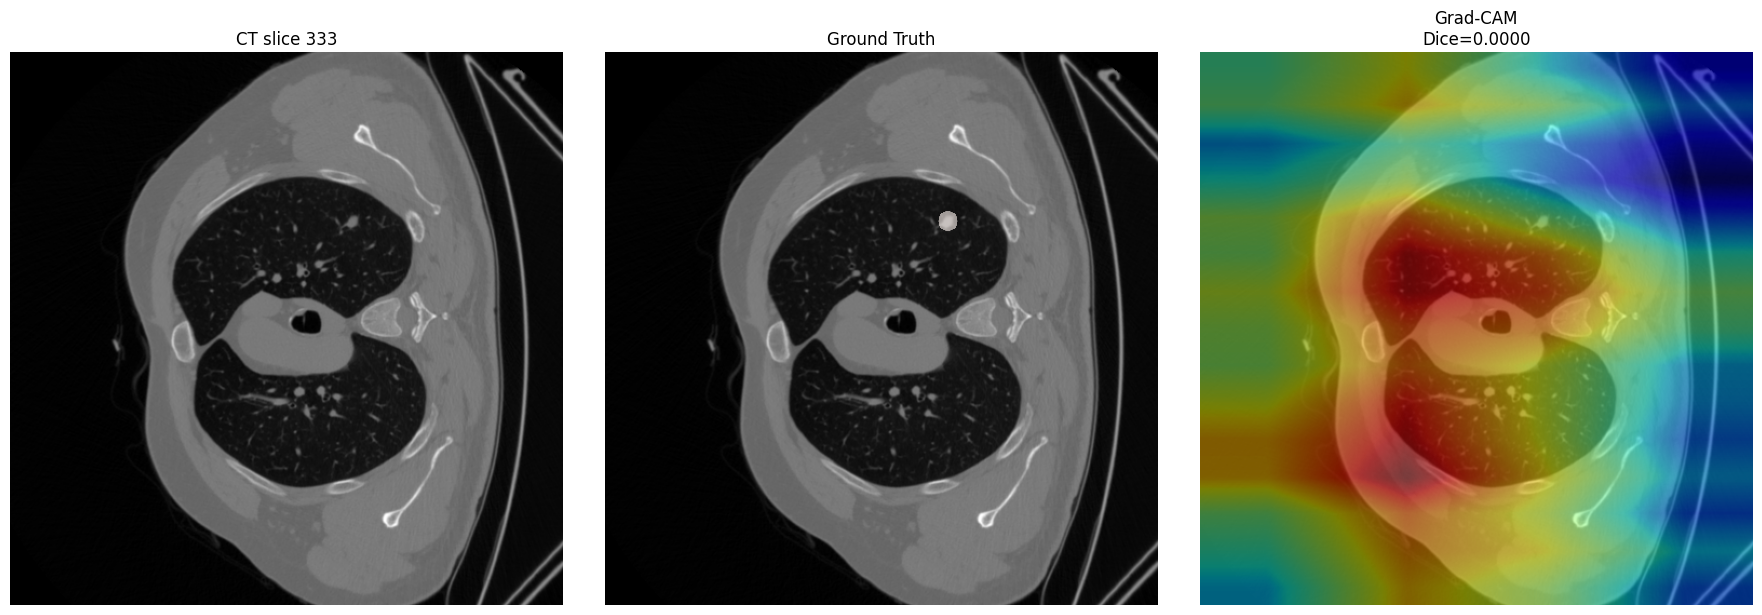

In [9]:
import os
import sys
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path)
assert os.path.exists(gt_path)



# ============================================================
# Load CT + GT
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()

gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0


print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.inference.predict import MerlinPredictor
from explainability.gradcam.gradcam3d import GradCAM3D
from explainability.gradcam.target import ImageEmbeddingNormTarget



model, target_layer = load_merlin(
    image_embedding_only=True
)


predictor = MerlinPredictor(
    model,
    image_embedding_only=True
)


device = next(model.parameters()).device


print(
    "Device:",
    device
)



# ============================================================
# Preprocess
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)


print("\nInput:")
print(image_tensor.shape)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    predictor.forward
)



cam = cam_generator(
    image_tensor,
    ImageEmbeddingNormTarget(),

    # FIX
    output_size=image_tensor.shape[2:]
)


cam_generator.release()


cam = np.asarray(cam)



print("\nCAM:")
print(cam.shape)



# ============================================================
# Compare GT at CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0]/gt_mask.shape[0],
        cam.shape[1]/gt_mask.shape[1],
        cam.shape[2]/gt_mask.shape[2]
    ),
    order=0
)


gt_small = gt_small > 0.5



print("\nLow resolution comparison")

print(
    "CAM:",
    cam.shape
)

print(
    "GT small:",
    gt_small.shape
)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")


for p in [80,85,90,95]:


    threshold = np.percentile(
        cam,
        p
    )


    cam_mask = cam >= threshold


    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()


    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )


    print(
        f"{p}%  Dice = {dice:.4f}"
    )



# ============================================================
# Best threshold
# ============================================================

threshold = np.percentile(
    cam,
    90
)


cam_mask_small = cam >= threshold



# ============================================================
# Pointing game
# ============================================================

max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)


pointing_result = gt_small[max_point]


print("\nPointing accuracy:")
print(
    "Hit:",
    bool(pointing_result)
)



# ============================================================
# Upsample CAM to CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0]/cam.shape[0],
        ct.shape[1]/cam.shape[1],
        ct.shape[2]/cam.shape[2]
    ),
    order=1
)


print("\nFull CAM:")
print(cam_full.shape)



# ============================================================
# Save CAM
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_gradcam.nii.gz"
)


print(
    "Saved CAM NIfTI"
)



# ============================================================
# Full resolution Dice
# ============================================================

cam_mask_full = cam_full >= np.percentile(
    cam_full,
    90
)



intersection = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


dice = (
    2*intersection /
    (
        cam_mask_full.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


print("\nFull resolution Dice:")
print(
    dice
)



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_idx}"
)

plt.axis("off")



# GT

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# CAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [25]:
import os
import sys
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch.nn.functional as F

from scipy.ndimage import zoom, label


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path)
assert os.path.exists(gt_path)



# ============================================================
# Load CT + GT
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)

ct = ct_nii.get_fdata()
gt = gt_nii.get_fdata()

if gt.ndim == 4:
    gt = gt[0]

gt_mask = gt > 0

print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin (image_embedding_only=True is fine — encode_text
# and encode_image are called directly below, bypassing the
# CLIP-style forward() that requires both image+text)
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.gradcam.gradcam3d import GradCAM3D


model, target_layer = load_merlin(
    image_embedding_only=True
)

device = next(model.parameters()).device

print("Device:", device)



# ============================================================
# Preprocess
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)

image_tensor = image_tensor.to(device)

print("\nInput:")
print(image_tensor.shape)



# ============================================================
# Text Similarity Target
# ============================================================

class TextSimilarityTarget:

    def __init__(self, model, text):
        self.model = model

        with torch.no_grad():
            text_embedding = model.model.encode_text([text])
            self.text_embedding = F.normalize(text_embedding, dim=-1)

    def __call__(self, output):
        image_embedding = F.normalize(output, dim=-1)
        similarity = (
            image_embedding *
            self.text_embedding.to(image_embedding.device)
        ).sum(dim=-1)
        return similarity



# ============================================================
# Image-only forward function (bypasses CLIP forward() which
# requires text; calls encode_image directly)
# ============================================================

def image_forward(x):
    return model.model.encode_image(x)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    image_forward
)

finding = "lung nodule"

target = TextSimilarityTarget(model, finding)

cam = cam_generator(
    image_tensor,
    target,
    output_size=image_tensor.shape[2:]
)

cam_generator.release()

cam = np.asarray(cam)

print("\nCAM:")
print(cam.shape)
print("CAM range:", cam.min(), cam.max())



# ============================================================
# Compare GT at CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0] / gt_mask.shape[0],
        cam.shape[1] / gt_mask.shape[1],
        cam.shape[2] / gt_mask.shape[2]
    ),
    order=0
)

gt_small = gt_small > 0.5

print("\nLow resolution comparison")
print("CAM:", cam.shape)
print("GT small:", gt_small.shape)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")
print(f"{'pct':>4} {'dice':>8} {'cam_voxels':>10}")

for p in np.arange(50, 100, 5):

    threshold = np.percentile(cam, p)
    cam_mask = cam >= threshold

    intersection = np.logical_and(cam_mask, gt_small).sum()

    dice = (
        2 * intersection /
        (cam_mask.sum() + gt_small.sum() + 1e-8)
    )

    print(f"{p:>4} {dice:>8.4f} {cam_mask.sum():>10}")



# ============================================================
# Pointing game (single max point)
# ============================================================

max_point = np.unravel_index(np.argmax(cam), cam.shape)
pointing_result = gt_small[max_point]

print("\nPointing accuracy (single max point):")
print("Max CAM location:", max_point)
print("Hit:", bool(pointing_result))



# ============================================================
# Pointing game (top-k voxels — fairer with multiple lesions)
# ============================================================

k = 50
flat_idx = np.argsort(cam.ravel())[-k:]
top_k_coords = np.array(np.unravel_index(flat_idx, cam.shape)).T
hits = [gt_small[tuple(c)] for c in top_k_coords]

print(f"\nTop-{k} pointing hits: {sum(hits)} / {k}")



# ============================================================
# Per-lesion breakdown (GT may contain several disjoint lesions)
# ============================================================

labeled_gt, n_lesions = label(gt_small)
print(f"\nNumber of separate lesion clusters (at CAM resolution): {n_lesions}")

for i in range(1, n_lesions + 1):
    lesion_mask = labeled_gt == i
    lesion_voxels = lesion_mask.sum()
    if lesion_voxels == 0:
        continue
    cam_at_lesion = cam[lesion_mask]
    print(
        f"Lesion {i}: {lesion_voxels} voxels, "
        f"max CAM = {cam_at_lesion.max():.4f}, "
        f"mean CAM = {cam_at_lesion.mean():.4f}"
    )



# ============================================================
# Upsample CAM to CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0] / cam.shape[0],
        ct.shape[1] / cam.shape[1],
        ct.shape[2] / cam.shape[2]
    ),
    order=1
)

print("\nFull CAM:")
print(cam_full.shape)



# ============================================================
# Save CAM
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)

nib.save(cam_nii, "train_1387_a_2_gradcam.nii.gz")

print("Saved CAM NIfTI")



# ============================================================
# Full resolution Dice
# ============================================================

cam_mask_full = cam_full >= np.percentile(cam_full, 90)

intersection = np.logical_and(cam_mask_full, gt_mask).sum()

dice = (
    2 * intersection /
    (cam_mask_full.sum() + gt_mask.sum() + 1e-8)
)

print("\nFull resolution Dice:")
print(dice)



# ============================================================
# Multi-prompt comparison (run other findings on same scan)
# ============================================================

print("\n===== Multi-prompt comparison =====")

findings = ["lung nodule", "ground glass opacity", "lung consolidation", "atelectasis"]

for f_text in findings:

    cam_generator_f = GradCAM3D(model, target_layer, image_forward)
    target_f = TextSimilarityTarget(model, f_text)

    cam_f = cam_generator_f(
        image_tensor,
        target_f,
        output_size=image_tensor.shape[2:]
    )
    cam_generator_f.release()
    cam_f = np.asarray(cam_f)

    threshold_f = np.percentile(cam_f, 90)
    cam_mask_f = cam_f >= threshold_f

    intersection_f = np.logical_and(cam_mask_f, gt_small).sum()
    dice_f = (
        2 * intersection_f /
        (cam_mask_f.sum() + gt_small.sum() + 1e-8)
    )

    max_point_f = np.unravel_index(np.argmax(cam_f), cam_f.shape)
    hit_f = bool(gt_small[max_point_f])

    print(f"{f_text:25s}  Dice@90%={dice_f:.4f}  PointingHit={hit_f}")



# ============================================================
# Visualization (using original "lung nodule" CAM)
# ============================================================

slice_idx = np.argmax(gt_mask.sum(axis=(0, 1)))

plt.figure(figsize=(18, 6))

# CT
plt.subplot(1, 3, 1)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.title(f"CT slice {slice_idx}")
plt.axis("off")

# GT
plt.subplot(1, 3, 2)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(
    np.ma.masked_where(
        gt_mask[:, :, slice_idx] == 0,
        gt_mask[:, :, slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)
plt.title("Ground Truth")
plt.axis("off")

# CAM
plt.subplot(1, 3, 3)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(cam_full[:, :, slice_idx], cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM ({finding})\nDice={dice:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT voxels: 7253
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Device: cuda:0

Input:
torch.Size([1, 1, 128, 128, 231])


RuntimeError: The size of tensor a (2048) must match the size of tensor b (512) at non-singleton dimension 2

In [26]:
import inspect

print(inspect.getsource(model.model.encode_image))
print("=" * 60)
print(inspect.getsource(type(model.model).forward))

TypeError: module, class, method, function, traceback, frame, or code object was expected, got ImageEncoder

In [28]:
import inspect
print(inspect.getsource(type(model.model.encode_image).forward))

    def forward(self, image):
        if self.ImageEmbedding:
            contrastive_features = self.i3_resnet(image)
            return contrastive_features
        elif self.PhenotypeCls:
            return self.i3_resnet(image)
        elif self.FiveYearPred:
            return self.i3_resnet(image)
        else:
            contrastive_features, ehr_features = self.i3_resnet(image)
            return contrastive_features, ehr_features



In [29]:
print(inspect.getsource(type(model.model.encode_image.i3_resnet).forward))

    def forward(self, x):
        skips = []
        x = x.permute(0, 1, 4, 2, 3)
        x = torch.cat((x, x, x), dim=1)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.maxpool(x)

        x = checkpoint.checkpoint(self.layer1, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer2, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer3, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer4, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))

        if self.conv_class:
            x_features = self.avgpool(x)

            if se

In [27]:
print(type(model.model.encode_image))
print(model.model.encode_image)

<class 'merlin.models.build.ImageEncoder'>
ImageEncoder(
  (i3_resnet): I3ResNet(
    (conv1): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), dilation=(1, 1, 1), ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck3d(
        (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [30]:
print(inspect.getsource(type(model.model.encode_image.i3_resnet).forward))

    def forward(self, x):
        skips = []
        x = x.permute(0, 1, 4, 2, 3)
        x = torch.cat((x, x, x), dim=1)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.maxpool(x)

        x = checkpoint.checkpoint(self.layer1, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer2, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer3, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer4, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))

        if self.conv_class:
            x_features = self.avgpool(x)

            if se

In [31]:
src = inspect.getsource(type(model.model.encode_image.i3_resnet).forward)
print(src)

    def forward(self, x):
        skips = []
        x = x.permute(0, 1, 4, 2, 3)
        x = torch.cat((x, x, x), dim=1)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = self.maxpool(x)

        x = checkpoint.checkpoint(self.layer1, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer2, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer3, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))
        x = checkpoint.checkpoint(self.layer4, x)
        if self.return_skips:
            skips.append(x.permute(0, 1, 3, 4, 2))

        if self.conv_class:
            x_features = self.avgpool(x)

            if se

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT voxels: 7253
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Merlin device: cuda:0

Input tensor:
torch.Size([1, 1, 128, 128, 231])

Image embedding: torch.Size([1, 512])
Text embedding: torch.Size([1, 512])

CAM:
(128, 128, 231)
Range: 0.0 1.0


/home/chest_ct/code/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



CAM resolution comparison
CAM: (128, 128, 231)
GT: (128, 128, 231)

Threshold evaluation
--------------------
70% Dice = 0.0003
75% Dice = 0.0003
80% Dice = 0.0004
85% Dice = 0.0005
90% Dice = 0.0005
95% Dice = 0.0008

Best CAM threshold: 0.5729471
Best low-res Dice: 0.0008022378212909271

Pointing accuracy: False

Full CAM: (512, 512, 461)
Saved CAM NIfTI

Final Grad-CAM Evaluation
Dice      : 0.0008
IoU       : 0.0004
Precision : 0.0004
Recall    : 0.3461


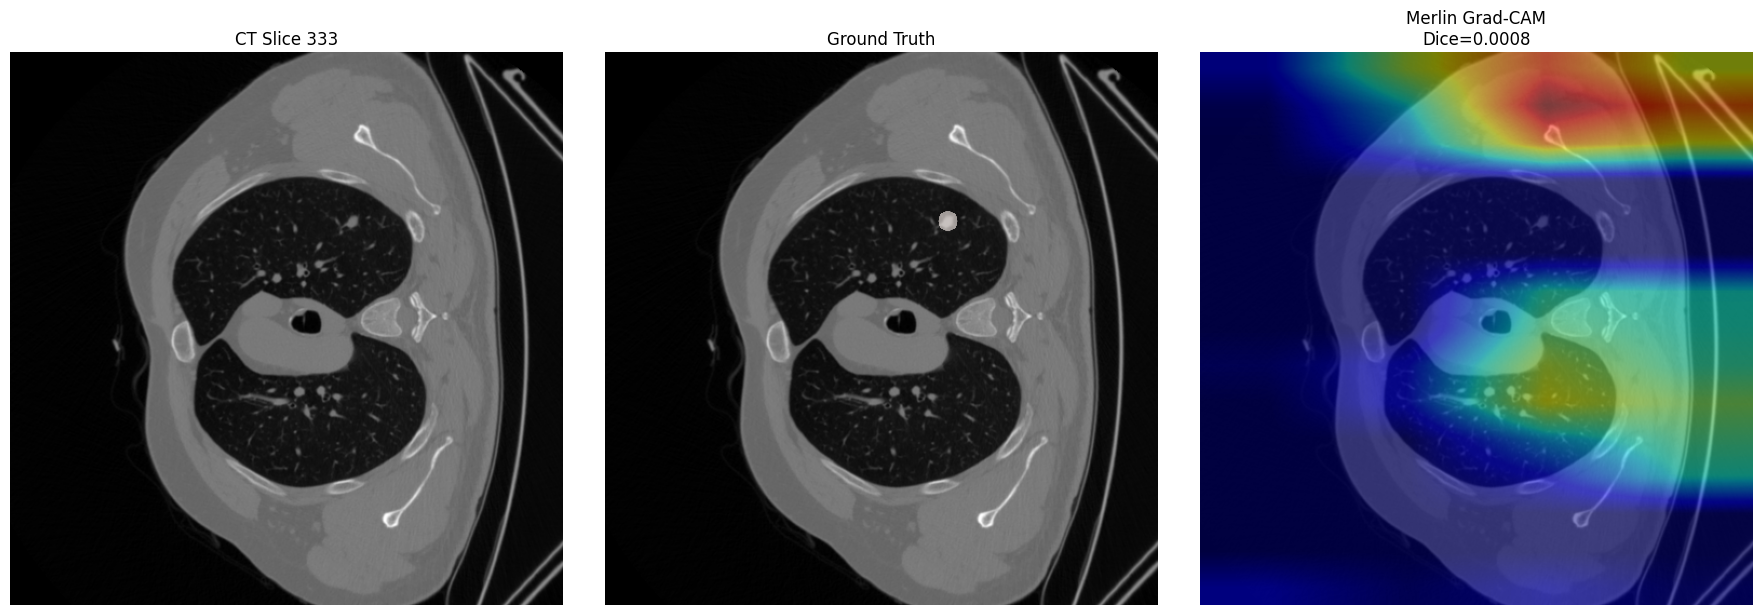

In [33]:
import os
import sys
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path), "CT not found"
assert os.path.exists(gt_path), "GT not found"



# ============================================================
# Load CT + Ground Truth
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()
gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0



print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.gradcam.gradcam3d import GradCAM3D



model, target_layer = load_merlin(
    image_embedding_only=True
)


device = next(model.parameters()).device


print(
    "Merlin device:",
    device
)



# ============================================================
# IMPORTANT FIX
# Enable contrastive projection head
# 2048 -> 512 embedding
# ============================================================

model.model.encode_image.i3_resnet.ImageEmbedding = False



# ============================================================
# Image forward for Grad-CAM
# ============================================================

def image_forward(x):

    output = model.model.encode_image(x)

    # ImageEmbedding=False returns:
    # (image_embedding, ehr_embedding)

    image_embedding, ehr_embedding = output

    return image_embedding



# ============================================================
# Text similarity target
# ============================================================

class TextSimilarityTarget:


    def __init__(self, model, text):

        with torch.no_grad():

            text_embedding = model.model.encode_text(
                [text]
            )


            self.text_embedding = F.normalize(
                text_embedding,
                dim=-1
            )


    def __call__(self, image_embedding):

        image_embedding = F.normalize(
            image_embedding,
            dim=-1
        )


        similarity = (
            image_embedding *
            self.text_embedding.to(
                image_embedding.device
            )
        ).sum(dim=-1)


        return similarity



# ============================================================
# Preprocess CT
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)



print("\nInput tensor:")
print(image_tensor.shape)



# ============================================================
# Verify embeddings
# ============================================================

with torch.no_grad():

    img_test = model.model.encode_image(
        image_tensor
    )

    img_test = img_test[0]


    txt_test = model.model.encode_text(
        ["lung nodule"]
    )


print(
    "\nImage embedding:",
    img_test.shape
)

print(
    "Text embedding:",
    txt_test.shape
)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    image_forward
)



finding = "lung nodule"


target = TextSimilarityTarget(
    model,
    finding
)



cam = cam_generator(
    image_tensor,
    target,
    output_size=image_tensor.shape[2:]
)



cam_generator.release()


cam = np.asarray(cam)



print("\nCAM:")
print(cam.shape)

print(
    "Range:",
    cam.min(),
    cam.max()
)



# ============================================================
# Resize GT to CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0]/gt_mask.shape[0],
        cam.shape[1]/gt_mask.shape[1],
        cam.shape[2]/gt_mask.shape[2]
    ),
    order=0
)


gt_small = gt_small > 0.5



print("\nCAM resolution comparison")

print(
    "CAM:",
    cam.shape
)

print(
    "GT:",
    gt_small.shape
)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")


best_dice = 0
best_threshold = 0


for p in [70,75,80,85,90,95]:


    threshold = np.percentile(
        cam,
        p
    )


    cam_mask = cam >= threshold


    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()


    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )


    print(
        f"{p}% Dice = {dice:.4f}"
    )


    if dice > best_dice:
        best_dice = dice
        best_threshold = threshold



print(
    "\nBest CAM threshold:",
    best_threshold
)

print(
    "Best low-res Dice:",
    best_dice
)



# ============================================================
# Pointing accuracy
# ============================================================

max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)


hit = gt_small[max_point]


print(
    "\nPointing accuracy:",
    bool(hit)
)



# ============================================================
# Resize CAM to full CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0]/cam.shape[0],
        ct.shape[1]/cam.shape[1],
        ct.shape[2]/cam.shape[2]
    ),
    order=1
)



print(
    "\nFull CAM:",
    cam_full.shape
)



# ============================================================
# Save CAM NIfTI
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_lung_nodule_gradcam.nii.gz"
)


print(
    "Saved CAM NIfTI"
)



# ============================================================
# Full resolution metrics
# ============================================================

cam_mask_full = cam_full >= best_threshold



intersection = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


union = np.logical_or(
    cam_mask_full,
    gt_mask
).sum()



dice = (
    2*intersection /
    (
        cam_mask_full.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


iou = intersection / (union + 1e-8)



tp = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


fp = np.logical_and(
    cam_mask_full,
    ~gt_mask
).sum()


fn = np.logical_and(
    ~cam_mask_full,
    gt_mask
).sum()



precision = tp/(tp+fp+1e-8)

recall = tp/(tp+fn+1e-8)



print("\n==============================")
print("Final Grad-CAM Evaluation")
print("==============================")

print(
    f"Dice      : {dice:.4f}"
)

print(
    f"IoU       : {iou:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT Slice {slice_idx}"
)

plt.axis("off")



# Ground truth

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# GradCAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Merlin Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")



plt.tight_layout()

plt.show()

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT voxels: 7253
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Merlin device: cuda:0

Input tensor:
torch.Size([1, 1, 128, 128, 231])
requires_grad: True

Image embedding: torch.Size([1, 512])
Text embedding: torch.Size([1, 512])

CAM:
(128, 128, 231)
Range: 0.0 1.0
Std: 0.19228698

CAM resolution comparison
CAM: (128, 128, 231)
GT: (128, 128, 231)

Threshold evaluation
--------------------
70% Dice = 0.0003
75% Dice = 0.0003
80% Dice = 0.0004
85% Dice = 0.0005
90% Dice = 0.0005
95% Dice = 0.0008

Best CAM threshold: 0.5729471
Best low-res Dice: 0.0008022378212909271

Pointing accuracy: False

Full CAM: (512, 512, 461)
Saved CAM NIfTI

Final Grad-CAM Evaluation
Dice      : 0.0008
IoU       : 0.0004
Precision : 0.0004
Recall    : 0.3461


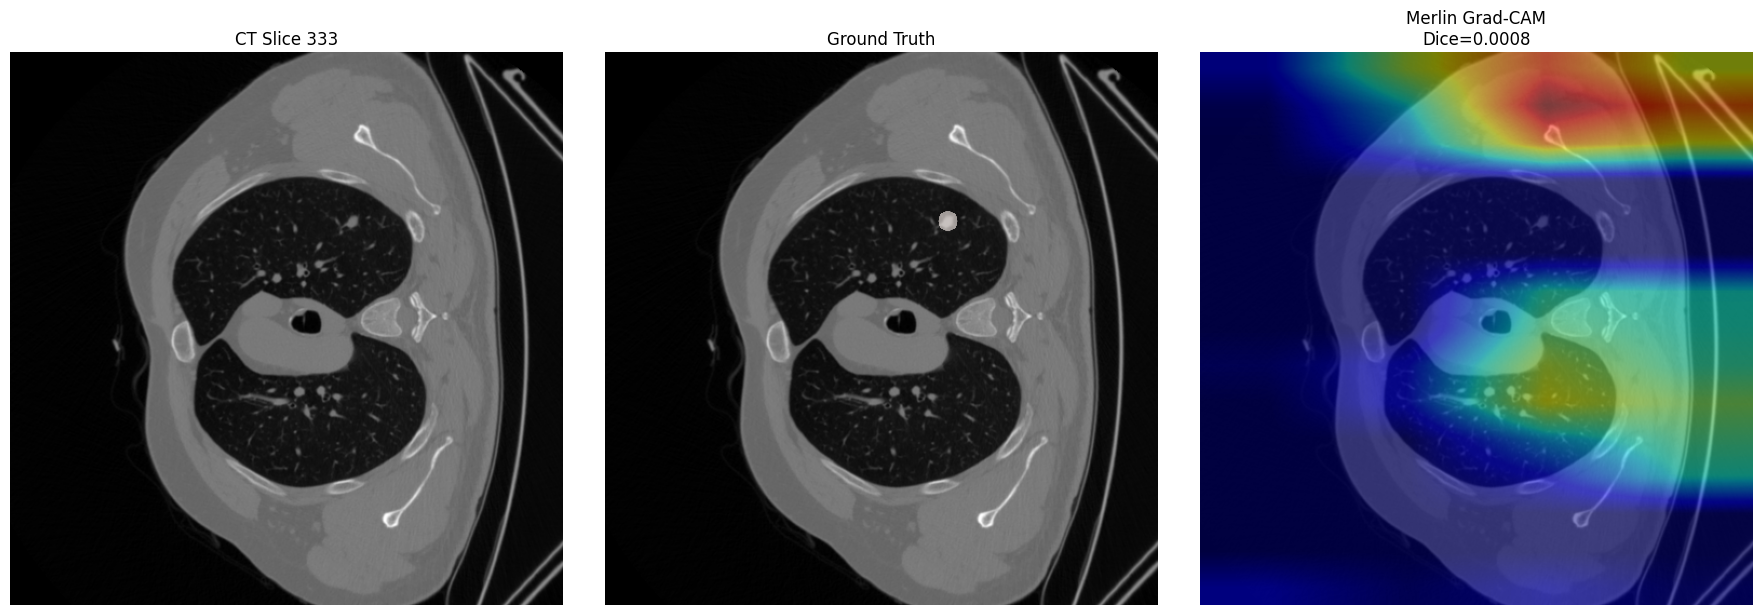

In [34]:
import os
import sys
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path), "CT not found"
assert os.path.exists(gt_path), "GT not found"



# ============================================================
# Load CT + Ground Truth
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()
gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0



print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.gradcam.gradcam3d import GradCAM3D



model, target_layer = load_merlin(
    image_embedding_only=True
)


device = next(model.parameters()).device


print(
    "Merlin device:",
    device
)



# ============================================================
# IMPORTANT FIX
# Enable contrastive projection head
# 2048 -> 512 embedding
# ============================================================

model.model.encode_image.i3_resnet.ImageEmbedding = False



# ============================================================
# Image forward for Grad-CAM
# ============================================================

def image_forward(x):

    output = model.model.encode_image(x)

    # ImageEmbedding=False returns:
    # (image_embedding, ehr_embedding)

    image_embedding, ehr_embedding = output

    return image_embedding



# ============================================================
# Text similarity target
# ============================================================

class TextSimilarityTarget:


    def __init__(self, model, text):

        with torch.no_grad():

            text_embedding = model.model.encode_text(
                [text]
            )


            self.text_embedding = F.normalize(
                text_embedding,
                dim=-1
            )


    def __call__(self, image_embedding):

        image_embedding = F.normalize(
            image_embedding,
            dim=-1
        )


        similarity = (
            image_embedding *
            self.text_embedding.to(
                image_embedding.device
            )
        ).sum(dim=-1)


        return similarity



# ============================================================
# Preprocess CT
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)


# ============================================================
# CRITICAL FIX
# Without this, torch.utils.checkpoint used inside I3ResNet's
# layer1-layer4 cannot properly backpropagate, gradients come
# back as None, and Grad-CAM silently produces a meaningless map
# ============================================================

image_tensor.requires_grad_(True)



print("\nInput tensor:")
print(image_tensor.shape)
print("requires_grad:", image_tensor.requires_grad)



# ============================================================
# Verify embeddings (sanity check only — no_grad here is fine,
# this is separate from the actual Grad-CAM forward pass below)
# ============================================================

with torch.no_grad():

    img_test = model.model.encode_image(
        image_tensor
    )

    img_test = img_test[0]


    txt_test = model.model.encode_text(
        ["lung nodule"]
    )


print(
    "\nImage embedding:",
    img_test.shape
)

print(
    "Text embedding:",
    txt_test.shape
)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    image_forward
)



finding = "lung nodule"


target = TextSimilarityTarget(
    model,
    finding
)



cam = cam_generator(
    image_tensor,
    target,
    output_size=image_tensor.shape[2:]
)



cam_generator.release()


cam = np.asarray(cam)



print("\nCAM:")
print(cam.shape)

print(
    "Range:",
    cam.min(),
    cam.max()
)

print(
    "Std:",
    cam.std()
)

# A near-zero std here would still indicate a degenerate/flat
# CAM even after fixing requires_grad — worth checking before
# trusting the Dice numbers below.



# ============================================================
# Resize GT to CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0]/gt_mask.shape[0],
        cam.shape[1]/gt_mask.shape[1],
        cam.shape[2]/gt_mask.shape[2]
    ),
    order=0
)


gt_small = gt_small > 0.5



print("\nCAM resolution comparison")

print(
    "CAM:",
    cam.shape
)

print(
    "GT:",
    gt_small.shape
)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")


best_dice = 0
best_threshold = 0


for p in [70,75,80,85,90,95]:


    threshold = np.percentile(
        cam,
        p
    )


    cam_mask = cam >= threshold


    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()


    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )


    print(
        f"{p}% Dice = {dice:.4f}"
    )


    if dice > best_dice:
        best_dice = dice
        best_threshold = threshold



print(
    "\nBest CAM threshold:",
    best_threshold
)

print(
    "Best low-res Dice:",
    best_dice
)



# ============================================================
# Pointing accuracy
# ============================================================

max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)


hit = gt_small[max_point]


print(
    "\nPointing accuracy:",
    bool(hit)
)



# ============================================================
# Resize CAM to full CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0]/cam.shape[0],
        ct.shape[1]/cam.shape[1],
        ct.shape[2]/cam.shape[2]
    ),
    order=1
)



print(
    "\nFull CAM:",
    cam_full.shape
)



# ============================================================
# Save CAM NIfTI
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_lung_nodule_gradcam.nii.gz"
)


print(
    "Saved CAM NIfTI"
)



# ============================================================
# Full resolution metrics
# ============================================================

cam_mask_full = cam_full >= best_threshold



intersection = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


union = np.logical_or(
    cam_mask_full,
    gt_mask
).sum()



dice = (
    2*intersection /
    (
        cam_mask_full.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


iou = intersection / (union + 1e-8)



tp = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


fp = np.logical_and(
    cam_mask_full,
    ~gt_mask
).sum()


fn = np.logical_and(
    ~cam_mask_full,
    gt_mask
).sum()



precision = tp/(tp+fp+1e-8)

recall = tp/(tp+fn+1e-8)



print("\n==============================")
print("Final Grad-CAM Evaluation")
print("==============================")

print(
    f"Dice      : {dice:.4f}"
)

print(
    f"IoU       : {iou:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT Slice {slice_idx}"
)

plt.axis("off")



# Ground truth

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# GradCAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Merlin Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")



plt.tight_layout()

plt.show()

In [32]:
with open("i3resnet_forward.txt", "w") as f:
    f.write(src)

print(len(src))

1907


In [11]:
positive_slices = np.where(
    gt_mask.sum(axis=(0,1)) > 0
)

print(
    "GT positive slices:",
    positive_slices[0]
)

GT positive slices: [168 169 170 171 172 173 174 175 176 177 178 179 180 181 203 204 205 206
 207 208 209 210 211 212 213 214 215 216 330 331 332 333 334 335 336 337
 338 339 340 341 342 343]


In [12]:
max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)

print(
    "Maximum CAM location:",
    max_point
)

print(
    "GT at maximum point:",
    gt_small[max_point]
)

Maximum CAM location: (np.int64(97), np.int64(48), np.int64(144))
GT at maximum point: False


In [13]:
thresholds = np.arange(50,100,5)

for p in thresholds:

    threshold = np.percentile(cam,p)

    cam_mask = cam >= threshold

    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()

    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )

    print(
        p,
        dice,
        cam_mask.sum()
    )

50 0.0002208629930845566 1892355
55 0.00017377643192366887 1703117
60 0.00019285345845031552 1513882
65 0.00021283388315419653 1324756
70 0.00011271127861259361 1135424
75 6.762489737393432e-05 946176
80 1.5848655901907177e-05 756941
85 0.0 568016
90 0.0 378490
95 0.0 189237


In [16]:
k = 50
flat_idx = np.argsort(cam.ravel())[-k:]
top_k_coords = np.array(np.unravel_index(flat_idx, cam.shape)).T

hits = [gt_small[tuple(c)] for c in top_k_coords]
print(f"Top-{k} pointing hits: {sum(hits)} / {k}")

Top-50 pointing hits: 0 / 50


In [17]:
thresholds = np.arange(50, 100, 5)

print(f"{'pct':>4} {'dice':>8} {'cam_voxels':>10}")
for p in thresholds:
    threshold = np.percentile(cam, p)
    cam_mask = cam >= threshold

    intersection = np.logical_and(cam_mask, gt_small).sum()
    dice = (
        2 * intersection /
        (cam_mask.sum() + gt_small.sum() + 1e-8)
    )

    print(f"{p:>4} {dice:>8.4f} {cam_mask.sum():>10}")

 pct     dice cam_voxels
  50   0.0002    1892355
  55   0.0002    1703117
  60   0.0002    1513882
  65   0.0002    1324756
  70   0.0001    1135424
  75   0.0001     946176
  80   0.0000     756941
  85   0.0000     568016
  90   0.0000     378490
  95   0.0000     189237


In [18]:
from scipy.ndimage import label

labeled_gt, n_lesions = label(gt_small)
print(f"Number of separate lesion clusters: {n_lesions}")

for i in range(1, n_lesions + 1):
    lesion_mask = labeled_gt == i
    lesion_voxels = lesion_mask.sum()
    cam_at_lesion = cam[lesion_mask]
    print(f"Lesion {i}: {lesion_voxels} voxels, "
          f"max CAM value inside = {cam_at_lesion.max():.4f}, "
          f"mean CAM value inside = {cam_at_lesion.mean():.4f}")

Number of separate lesion clusters: 3
Lesion 1: 70 voxels, max CAM value inside = 0.6807, mean CAM value inside = 0.6329
Lesion 2: 76 voxels, max CAM value inside = 0.6082, mean CAM value inside = 0.5917
Lesion 3: 75 voxels, max CAM value inside = 0.5180, mean CAM value inside = 0.4990


In [19]:
findings = ["lung nodule", "ground glass opacity", "lung consolidation", "atelectasis"]

for finding in findings:
    target = TextSimilarityTarget(model, finding)
    cam_f = cam_generator(image_tensor, target, output_size=image_tensor.shape[2:])
    cam_generator.release()
    cam_f = np.asarray(cam_f)

    threshold = np.percentile(cam_f, 90)
    cam_mask = cam_f >= threshold
    intersection = np.logical_and(cam_mask, gt_small).sum()
    dice = 2*intersection / (cam_mask.sum() + gt_small.sum() + 1e-8)

    max_point = np.unravel_index(np.argmax(cam_f), cam_f.shape)
    hit = bool(gt_small[max_point])

    print(f"{finding:25s}  Dice@90%={dice:.4f}  PointingHit={hit}")

ValueError: Text input required for Image and Text embedding

In [20]:
print(model)

Merlin(
  (model): MerlinArchitecture(
    (encode_image): ImageEncoder(
      (i3_resnet): I3ResNet(
        (conv1): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), dilation=(1, 1, 1), ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck3d(
            (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=Fa

In [21]:
print(predictor.image_embedding_only)

True


In [22]:
import inspect

print(inspect.getsource(predictor.forward))

    def forward(self, image_tensor, text=None):
        if self.image_embedding_only:
            return self.model(image_tensor)
        assert text is not None, "text is required when image_embedding_only=False"
        return self.model(image_tensor, [text])



In [23]:
print("Predictor mode:", predictor.image_embedding_only)
print("Model attributes:")

for attr in dir(model):
    if "image" in attr.lower() or "text" in attr.lower():
        print(attr)

Predictor mode: True
Model attributes:


In [24]:
print(model)

Merlin(
  (model): MerlinArchitecture(
    (encode_image): ImageEncoder(
      (i3_resnet): I3ResNet(
        (conv1): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), dilation=(1, 1, 1), ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck3d(
            (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=Fa

In [10]:
import os
import sys
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


assert os.path.exists(ct_path)
assert os.path.exists(gt_path)



# ============================================================
# Load CT + GT
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()

gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0


print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.inference.predict import MerlinPredictor
from explainability.gradcam.gradcam3d import GradCAM3D

import torch.nn.functional as F



model, target_layer = load_merlin(
    image_embedding_only=False
)


predictor = MerlinPredictor(
    model,
    image_embedding_only=True
)




device = next(model.parameters()).device

# ============================================================
# Text Similarity Target
# ============================================================

class TextSimilarityTarget:

    def __init__(self, model, text):

        self.model = model

        with torch.no_grad():

            text_embedding = model.model.encode_text(
                [text]
            )

            self.text_embedding = F.normalize(
                text_embedding,
                dim=-1
            )


    def __call__(self, output):

        image_embedding = F.normalize(
            output,
            dim=-1
        )


        similarity = (
            image_embedding *
            self.text_embedding.to(
                image_embedding.device
            )
        ).sum(dim=-1)


        return similarity
print(
    "Device:",
    device
)



# ============================================================
# Preprocess
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)


print("\nInput:")
print(image_tensor.shape)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    predictor.forward
)


finding = "lung nodule"


target = TextSimilarityTarget(
    model,
    finding
)


cam = cam_generator(
    image_tensor,
    target,
    output_size=image_tensor.shape[2:]
)

cam_generator.release()


cam = np.asarray(cam)



print("\nCAM:")
print(cam.shape)



# ============================================================
# Compare GT at CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0]/gt_mask.shape[0],
        cam.shape[1]/gt_mask.shape[1],
        cam.shape[2]/gt_mask.shape[2]
    ),
    order=0
)


gt_small = gt_small > 0.5



print("\nLow resolution comparison")

print(
    "CAM:",
    cam.shape
)

print(
    "GT small:",
    gt_small.shape
)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")


for p in [80,85,90,95]:


    threshold = np.percentile(
        cam,
        p
    )


    cam_mask = cam >= threshold


    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()


    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )


    print(
        f"{p}%  Dice = {dice:.4f}"
    )



# ============================================================
# Best threshold
# ============================================================

threshold = np.percentile(
    cam,
    90
)


cam_mask_small = cam >= threshold



# ============================================================
# Pointing game
# ============================================================

max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)


pointing_result = gt_small[max_point]


print("\nPointing accuracy:")
print(
    "Hit:",
    bool(pointing_result)
)



# ============================================================
# Upsample CAM to CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0]/cam.shape[0],
        ct.shape[1]/cam.shape[1],
        ct.shape[2]/cam.shape[2]
    ),
    order=1
)


print("\nFull CAM:")
print(cam_full.shape)



# ============================================================
# Save CAM
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_gradcam.nii.gz"
)


print(
    "Saved CAM NIfTI"
)



# ============================================================
# Full resolution Dice
# ============================================================

cam_mask_full = cam_full >= np.percentile(
    cam_full,
    90
)



intersection = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


dice = (
    2*intersection /
    (
        cam_mask_full.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


print("\nFull resolution Dice:")
print(
    dice
)



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_idx}"
)

plt.axis("off")



# GT

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# CAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")


plt.tight_layout()
plt.show()

CT shape : (512, 512, 461)
GT shape : (512, 512, 461)
GT voxels: 7253
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Device: cuda:0


Input ids are automatically padded to be a multiple of `config.attention_window`: 512



Input:
torch.Size([1, 1, 128, 128, 231])


ValueError: Text input required for Image and Text embedding

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# Paths
# ============================================================

official_cam_path = "/home/chest_ct/code/models/merlin/gradcam_outputs/official_gradcam.nii.gz"

my_cam_path = "/home/chest_ct/code/models/merlin/my_gradcam.nii.gz"

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"



assert os.path.exists(official_cam_path), "Official CAM not found"
assert os.path.exists(my_cam_path), "Your CAM not found"
assert os.path.exists(ct_path), "CT not found"
assert os.path.exists(gt_path), "GT not found"



# ============================================================
# Load files
# ============================================================

official_cam = nib.load(
    official_cam_path
).get_fdata()


my_cam = nib.load(
    my_cam_path
).get_fdata()


ct = nib.load(
    ct_path
).get_fdata()


gt = nib.load(
    gt_path
).get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0



print("Official CAM:", official_cam.shape)
print("My CAM      :", my_cam.shape)
print("CT          :", ct.shape)
print("GT          :", gt_mask.shape)



# ============================================================
# Shape check
# ============================================================

assert official_cam.shape == my_cam.shape, \
    "CAM shapes are different"


assert official_cam.shape == ct.shape, \
    "CAM and CT shapes are different"



# ============================================================
# Normalize CAMs
# ============================================================

def normalize(cam):

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    return cam



official_cam = normalize(
    official_cam
)


my_cam = normalize(
    my_cam
)



# ============================================================
# Pearson correlation
# ============================================================

pearson, p = pearsonr(
    official_cam.flatten(),
    my_cam.flatten()
)


print("\n============================")
print("CAM Similarity")
print("============================")


print(
    f"Pearson correlation : {pearson:.6f}"
)



# ============================================================
# Cosine similarity
# ============================================================

cos = cosine_similarity(
    official_cam.reshape(1,-1),
    my_cam.reshape(1,-1)
)[0][0]


print(
    f"Cosine similarity   : {cos:.6f}"
)



# ============================================================
# Mean Absolute Error
# ============================================================

mae = np.mean(
    np.abs(
        official_cam -
        my_cam
    )
)


print(
    f"MAE                 : {mae:.6f}"
)



# ============================================================
# Threshold comparison
# ============================================================

threshold = 90


official_mask = (
    official_cam >=
    np.percentile(
        official_cam,
        threshold
    )
)


my_mask = (
    my_cam >=
    np.percentile(
        my_cam,
        threshold
    )
)



def dice_score(a,b):

    intersection = np.logical_and(
        a,b
    ).sum()


    return (
        2*intersection /
        (
            a.sum()
            +
            b.sum()
            +
            1e-8
        )
    )



print("\nCAM binary overlap")
print("------------------")


print(
    "Dice:",
    dice_score(
        official_mask,
        my_mask
    )
)



# ============================================================
# Find lesion slice
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


print(
    "\nVisualization slice:",
    slice_idx
)



# ============================================================
# Visualization
# ============================================================

plt.figure(
    figsize=(20,8)
)



# CT

plt.subplot(2,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    "CT"
)

plt.axis("off")



# GT

plt.subplot(2,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# Official CAM

plt.subplot(2,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    official_cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    "Official Merlin Grad-CAM"
)

plt.axis("off")



# Your CAM

plt.subplot(2,3,4)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    my_cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    "Your Grad-CAM"
)

plt.axis("off")



# Difference

plt.subplot(2,3,5)

plt.imshow(
    np.abs(
        official_cam[:,:,slice_idx]
        -
        my_cam[:,:,slice_idx]
    ),
    cmap="hot"
)


plt.title(
    "Absolute Difference"
)

plt.axis("off")



# Scatter

plt.subplot(2,3,6)


plt.scatter(
    official_cam.flatten()[::100],
    my_cam.flatten()[::100],
    s=1
)

 
plt.xlabel(
    "Official CAM"
)

plt.ylabel(
    "Your CAM"
)

plt.title(
    "CAM Correlation"
)



plt.tight_layout()

plt.show()

AssertionError: Official CAM not found

In [8]:
print("GT slices with lesion:")

slices = np.where(
    gt_mask.sum(axis=(0,1)) > 0
)[0]

print(slices[:20])
print("Number of positive slices:", len(slices))

GT slices with lesion:
[168 169 170 171 172 173 174 175 176 177 178 179 180 181 203 204 205 206
 207 208]
Number of positive slices: 42


CT: (512, 512, 512)
Mask: (6, 512, 512, 512)
Binary mask: (512, 512, 512)
Foreground voxels: 52340

Bounding box
(np.int64(160), np.int64(353), np.int64(188), np.int64(235), np.int64(372), np.int64(405))

Collected patches: 3725

Patch index: 1536
Origin: (267, 201, 379)
Lesion fraction: 0.620361328125
Patch L2 norm: 49362.80349615488


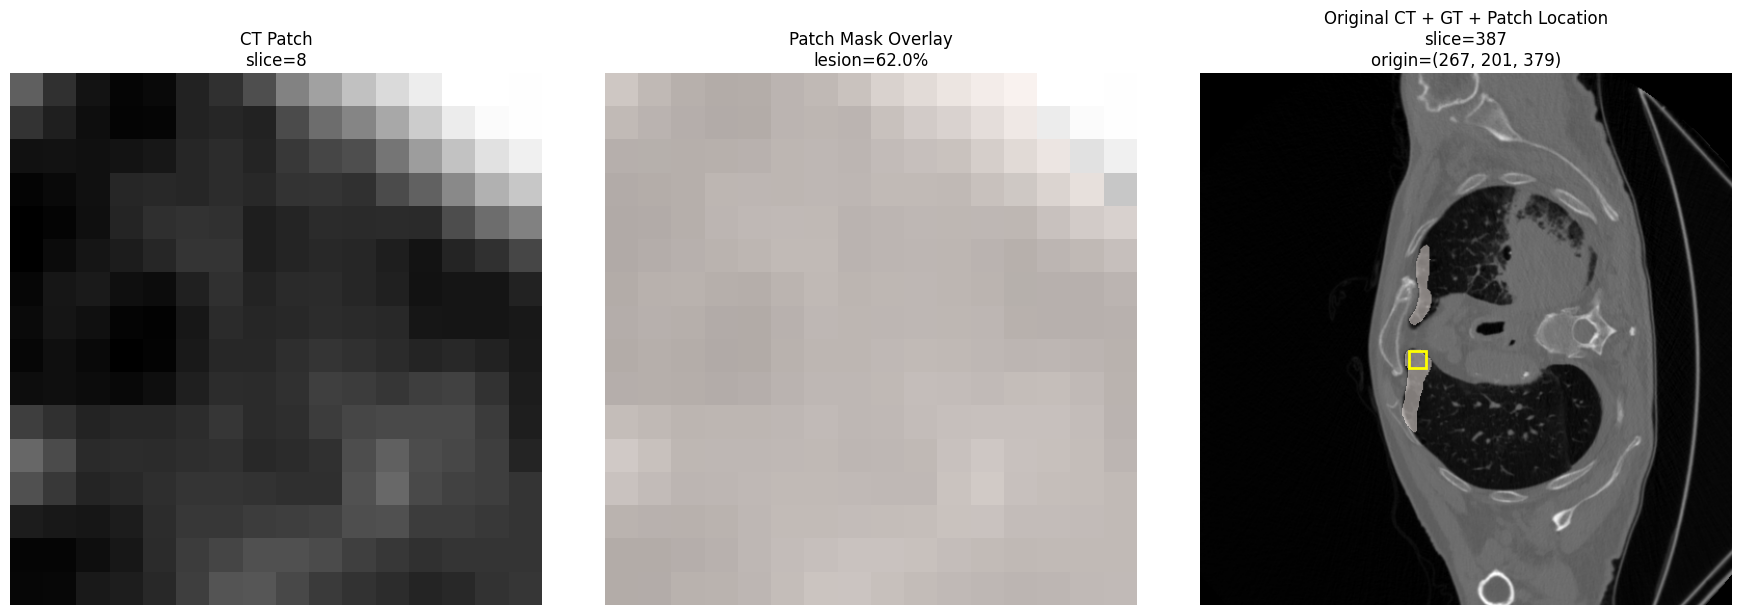


Patch index: 1020
Origin: (223, 209, 373)
Lesion fraction: 0.84716796875
Patch L2 norm: 51670.47874754017


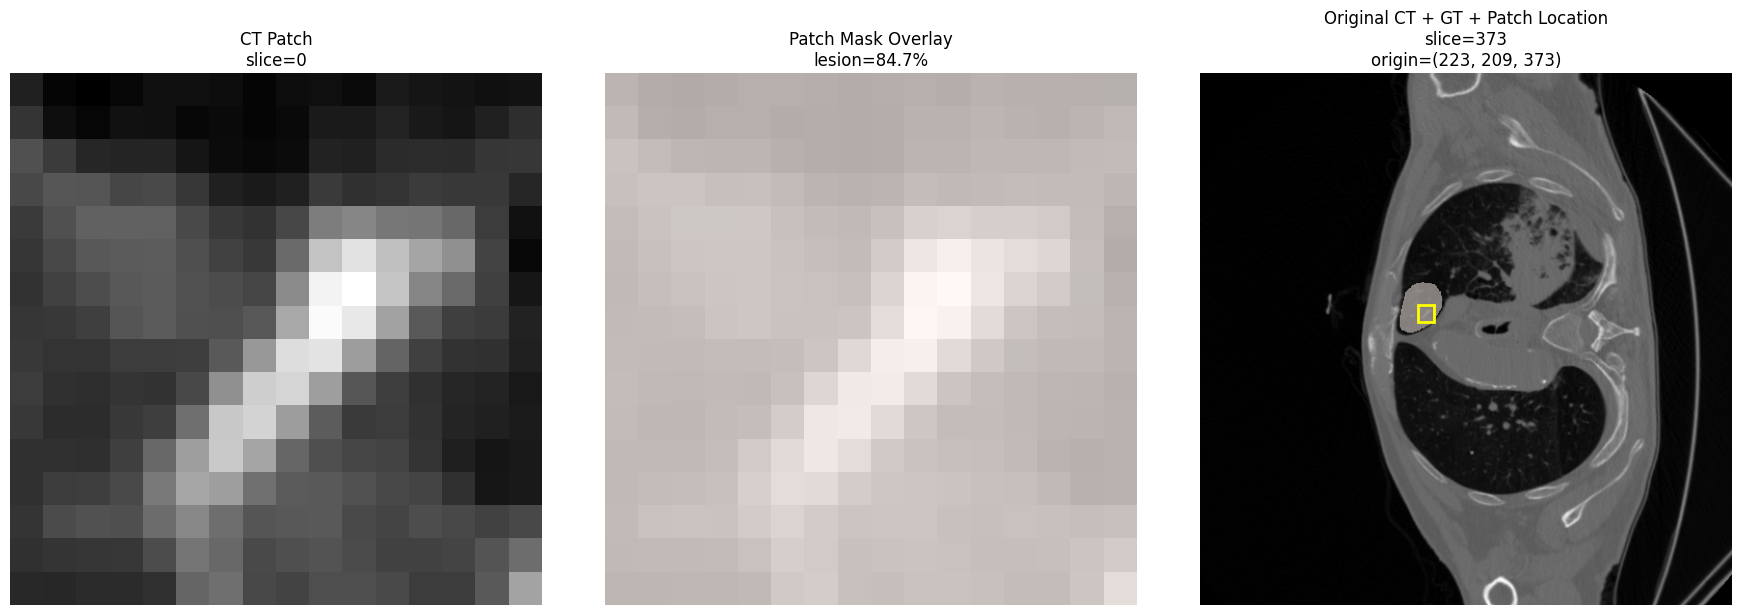


Patch index: 9
Origin: (189, 207, 375)
Lesion fraction: 0.50927734375
Patch L2 norm: 53950.30781191151


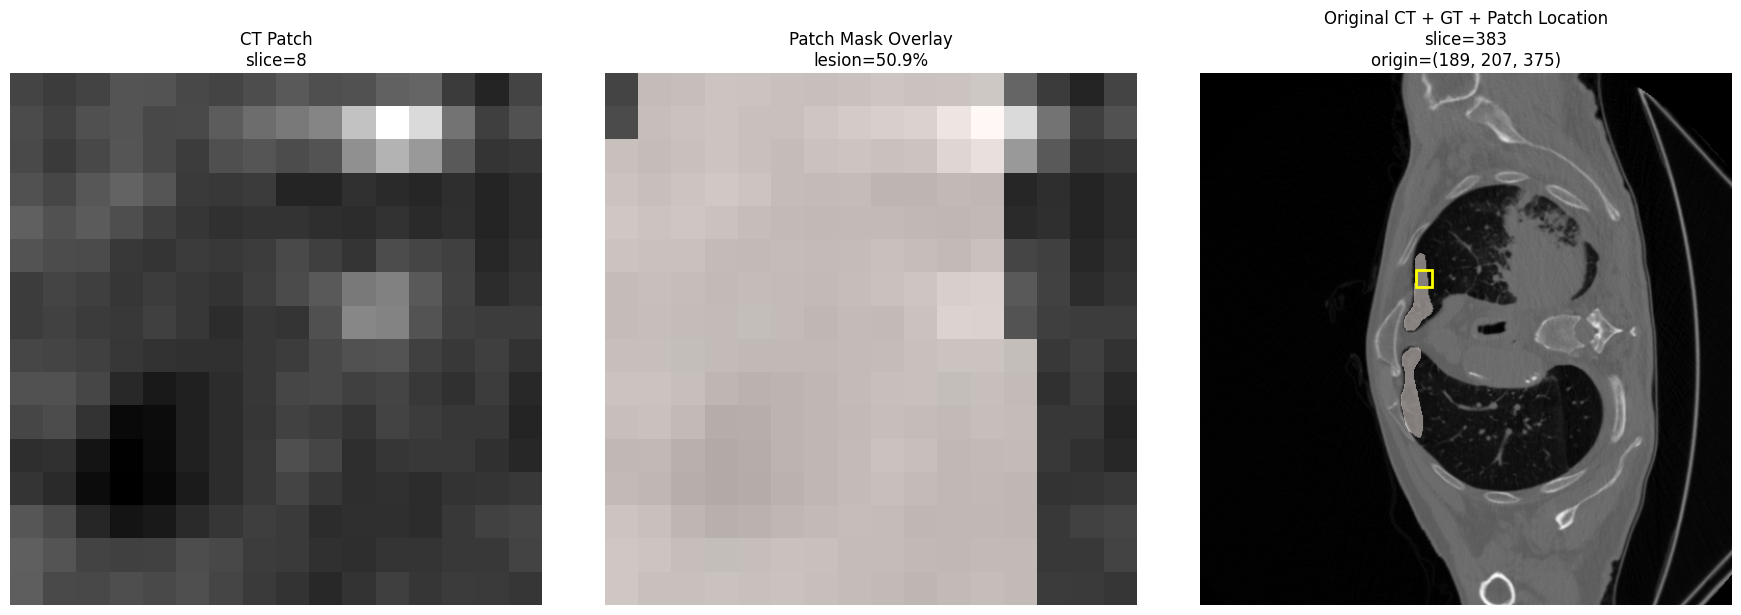


Patch index: 2105
Origin: (301, 193, 381)
Lesion fraction: 0.584716796875
Patch L2 norm: 44941.713296224036


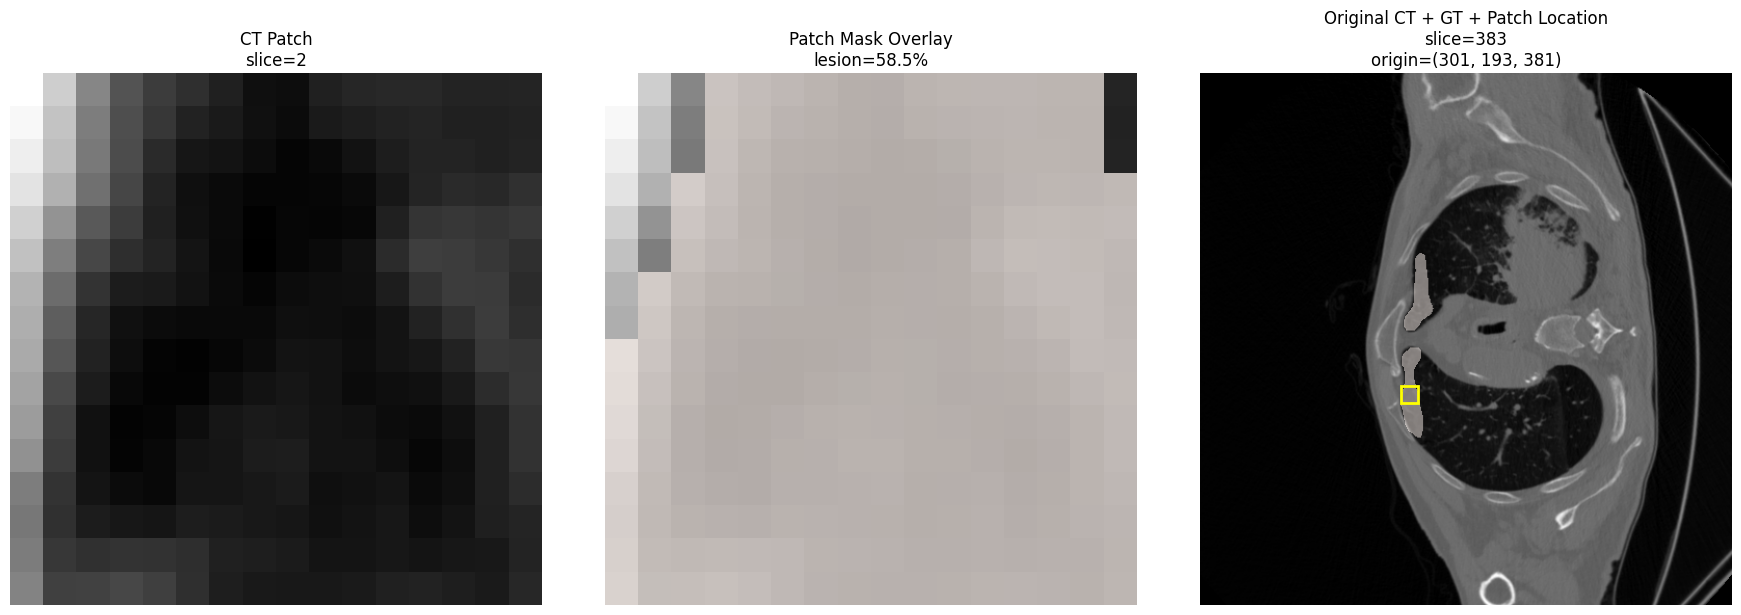


Patch index: 3467
Origin: (327, 207, 389)
Lesion fraction: 0.761962890625
Patch L2 norm: 54874.58938342956


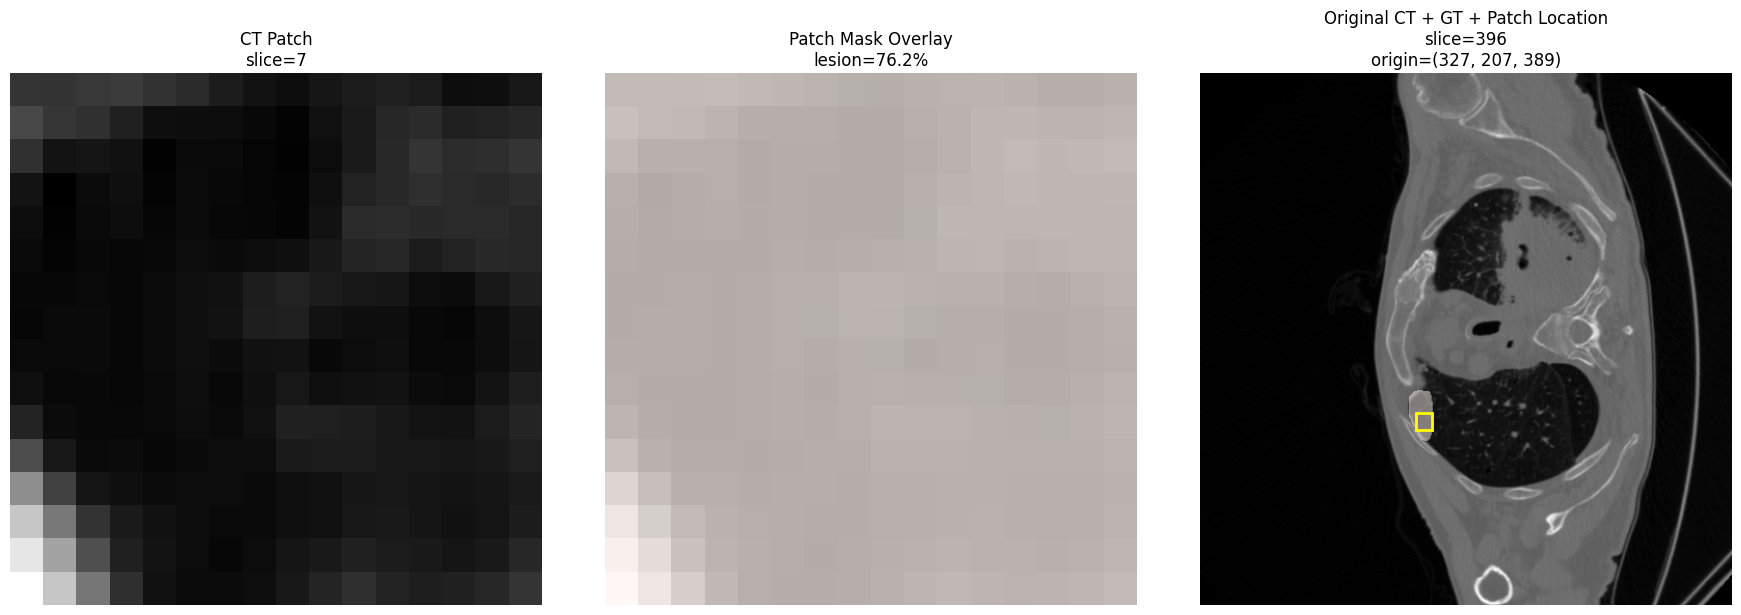

In [24]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# =============================
# Parameters (same as pipeline)
# =============================

PATCH_SIZE = 16
ABNORMAL_PATCH_STRIDE = 2
LESION_FRACTION_THRESHOLD = 0.5


# =============================
# Load CT and mask
# =============================

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1448_c_2.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_1448_c_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
mask = nib.load(mask_path).get_fdata()


print("CT:", ct.shape)
print("Mask:", mask.shape)


# Handle 4D masks
if mask.ndim == 4:
    finding = 0
    mask = mask[finding]


mask = (mask > 0).astype(np.uint8)

print("Binary mask:", mask.shape)
print("Foreground voxels:", mask.sum())



# =============================
# Helper functions (same logic)
# =============================

def has_sufficient_lesion(mask_patch):
    return (mask_patch > 0).mean() >= LESION_FRACTION_THRESHOLD



def foreground_bbox(binary_mask):

    coords = np.argwhere(binary_mask > 0)

    x_min, y_min, z_min = coords.min(axis=0)
    x_max, y_max, z_max = coords.max(axis=0)

    return (
        x_min, x_max,
        y_min, y_max,
        z_min, z_max
    )



def bbox_origins(bbox, volume_shape, stride):

    p = PATCH_SIZE

    H, W, D = volume_shape

    x_min, x_max, y_min, y_max, z_min, z_max = bbox


    x_start = max(0, x_min - p + 1)
    x_stop  = min(H-p, x_max)

    y_start = max(0, y_min - p + 1)
    y_stop  = min(W-p, y_max)

    z_start = max(0, z_min - p + 1)
    z_stop  = min(D-p, z_max)


    for x0 in range(x_start, x_stop+1, stride):
        for y0 in range(y_start, y_stop+1, stride):
            for z0 in range(z_start, z_stop+1, stride):
                yield x0,y0,z0



def extract_patch(volume, x,y,z):

    return volume[
        x:x+PATCH_SIZE,
        y:y+PATCH_SIZE,
        z:z+PATCH_SIZE
    ]



# =============================
# Generate patches
# =============================

bbox = foreground_bbox(mask)

print("\nBounding box")
print(bbox)


patches = []


for x,y,z in bbox_origins(
    bbox,
    ct.shape,
    ABNORMAL_PATCH_STRIDE
):

    ct_patch = extract_patch(ct,x,y,z)
    mask_patch = extract_patch(mask,x,y,z)


    if has_sufficient_lesion(mask_patch):

        patches.append(
            {
                "origin":(x,y,z),
                "ct":ct_patch,
                "mask":mask_patch,
                "lesion_fraction":(mask_patch>0).mean()
            }
        )


print("\nCollected patches:",len(patches))



# =============================
# Visualize selected patches
# =============================

def show_patch(patch):

    ct_patch = patch["ct"]
    mask_patch = patch["mask"]

    x0, y0, z0 = patch["origin"]


    # choose patch slice with highest lesion pixels
    slice_idx = np.argmax(
        (mask_patch > 0).sum(axis=(0,1))
    )

    # Corresponding slice in original CT
    original_z = z0 + slice_idx


    fig, ax = plt.subplots(
        1, 3,
        figsize=(18, 6)
    )


    # ---------------------------------
    # 1. Patch CT
    # ---------------------------------

    ax[0].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[0].set_title(
        f"CT Patch\nslice={slice_idx}"
    )

    ax[0].axis("off")



    # ---------------------------------
    # 2. Patch + mask overlay
    # ---------------------------------

    ax[1].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[1].imshow(
        np.ma.masked_where(
            mask_patch[:, :, slice_idx] == 0,
            mask_patch[:, :, slice_idx]
        ),
        cmap="Reds",
        alpha=0.7
    )

    ax[1].set_title(
        f"Patch Mask Overlay\n"
        f"lesion={patch['lesion_fraction']*100:.1f}%"
    )

    ax[1].axis("off")



    # ---------------------------------
    # 3. Original CT + GT + patch box
    # ---------------------------------

    ax[2].imshow(
        ct[:, :, original_z],
        cmap="gray"
    )


    # Full GT mask overlay
    ax[2].imshow(
        np.ma.masked_where(
            mask[:, :, original_z] == 0,
            mask[:, :, original_z]
        ),
        cmap="Reds",
        alpha=0.5
    )


    # Draw patch bounding box
    rect = plt.Rectangle(
        (y0, x0),
        PATCH_SIZE,
        PATCH_SIZE,
        fill=False,
        edgecolor="yellow",
        linewidth=2
    )

    ax[2].add_patch(rect)


    ax[2].set_title(
        f"Original CT + GT + Patch Location\n"
        f"slice={original_z}\n"
        f"origin={patch['origin']}"
    )

    ax[2].axis("off")


    plt.tight_layout()
    plt.show()



import numpy as np

# Number of random patches to display
num_show = 5

# Select random patch indices
random_indices = np.random.choice(
    len(patches),
    size=min(num_show, len(patches)),
    replace=False
)


for i in random_indices:

    p = patches[i]

    patch_norm = np.linalg.norm(p["ct"])


    print(
        f"\nPatch index: {i}"
    )

    print(
        "Origin:",
        p["origin"]
    )

    print(
        "Lesion fraction:",
        p["lesion_fraction"]
    )

    print(
        "Patch L2 norm:",
        patch_norm
    )

    show_patch(p)

In [3]:
import numpy as np

patch_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz"

data = np.load(
    patch_path,
    allow_pickle=True
)

print("Keys:", data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

Keys: ['X', 'H', 'scan_ids']
X (4096, 143173) float64
H (143173,) int64
scan_ids (143173,) object


In [4]:
scan_ids = data["scan_ids"]
X = data["X"]
norms = np.linalg.norm(X, axis=0)

zero_scan_indices = np.where(
    scan_ids == "train_1448_c_2.nii.gz"
)[0]

print("\nIndices of patches from scan 'train_1448_c_2.nii.gz':", zero_scan_indices)

for idx in zero_scan_indices[:20]:

    print(
        idx,
        norms[idx],
        X[:,idx].min(),
        X[:,idx].max()
    )


Indices of patches from scan 'train_1448_c_2.nii.gz': []


In [5]:
X = data["X"]

print("Patch matrix shape:", X.shape)

# Each column = one patch
patch_norms = np.linalg.norm(X, axis=0)

zero_mask = patch_norms < 1e-10


print("\n===== Patch Norm Statistics =====")
print("Total patches:", X.shape[1])
print("Zero norm patches:", zero_mask.sum())

print(
    f"Percentage zero norm patches: "
    f"{zero_mask.sum()/X.shape[1]*100:.6f}%"
)


print("\nNorm statistics")
print("Min norm:", patch_norms.min())
print("Max norm:", patch_norms.max())
print("Mean norm:", patch_norms.mean())
print("Median norm:", np.median(patch_norms))

Patch matrix shape: (4096, 143173)

===== Patch Norm Statistics =====
Total patches: 143173
Zero norm patches: 7971
Percentage zero norm patches: 5.567390%

Norm statistics
Min norm: 0.0
Max norm: 39.01872626073064
Mean norm: 14.58733136788172
Median norm: 14.969491596791684


In [ ]:
import numpy as np

patch_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz"

data = np.load(
    patch_path,
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]

# Compute norms
patch_norms = np.linalg.norm(X, axis=0)

# Find zero norm patches
zero_mask = patch_norms < 1e-10

# Get scan IDs corresponding to zero norm patches
zero_norm_scan_ids = scan_ids[zero_mask]


print("Number of zero norm patches:", len(zero_norm_scan_ids))

print("\nFirst 20 zero norm patch scan IDs:")
print(zero_norm_scan_ids[:20])

Number of zero norm patches: 7971

First 20 zero norm patch scan IDs:
['train_5668_a_2' 'train_5668_a_2' 'train_5668_a_2' ... 'train_7244_a_1'
 'train_7244_a_1' 'train_7244_a_1']


In [7]:
unique_zero_scan_ids, counts = np.unique(
    zero_norm_scan_ids,
    return_counts=True
)

print("Number of scans containing zero-norm patches:",
      len(unique_zero_scan_ids))

for scan_id, count in zip(unique_zero_scan_ids, counts):
    print(scan_id, "->", count, "zero-norm patches")

Number of scans containing zero-norm patches: 19
train_11536_a_2 -> 17 zero-norm patches
train_122_b_1 -> 1061 zero-norm patches
train_1269_a_2 -> 40 zero-norm patches
train_1329_b_1 -> 1 zero-norm patches
train_1448_c_2 -> 167 zero-norm patches
train_1686_a_1 -> 3 zero-norm patches
train_2250_a_2 -> 684 zero-norm patches
train_2333_a_2 -> 278 zero-norm patches
train_5668_a_2 -> 2979 zero-norm patches
train_5803_a_2 -> 278 zero-norm patches
train_6345_a_2 -> 2008 zero-norm patches
train_6345_b_2 -> 253 zero-norm patches
train_6694_d_2 -> 9 zero-norm patches
train_6721_b_1 -> 10 zero-norm patches
train_6970_a_2 -> 29 zero-norm patches
train_6970_b_2 -> 51 zero-norm patches
train_7244_a_1 -> 39 zero-norm patches
train_7641_b_2 -> 29 zero-norm patches
train_7737_b_2 -> 35 zero-norm patches


GT shape: (512, 512, 461)
Displaying slice: 333
Otsu threshold: -466.8 HU


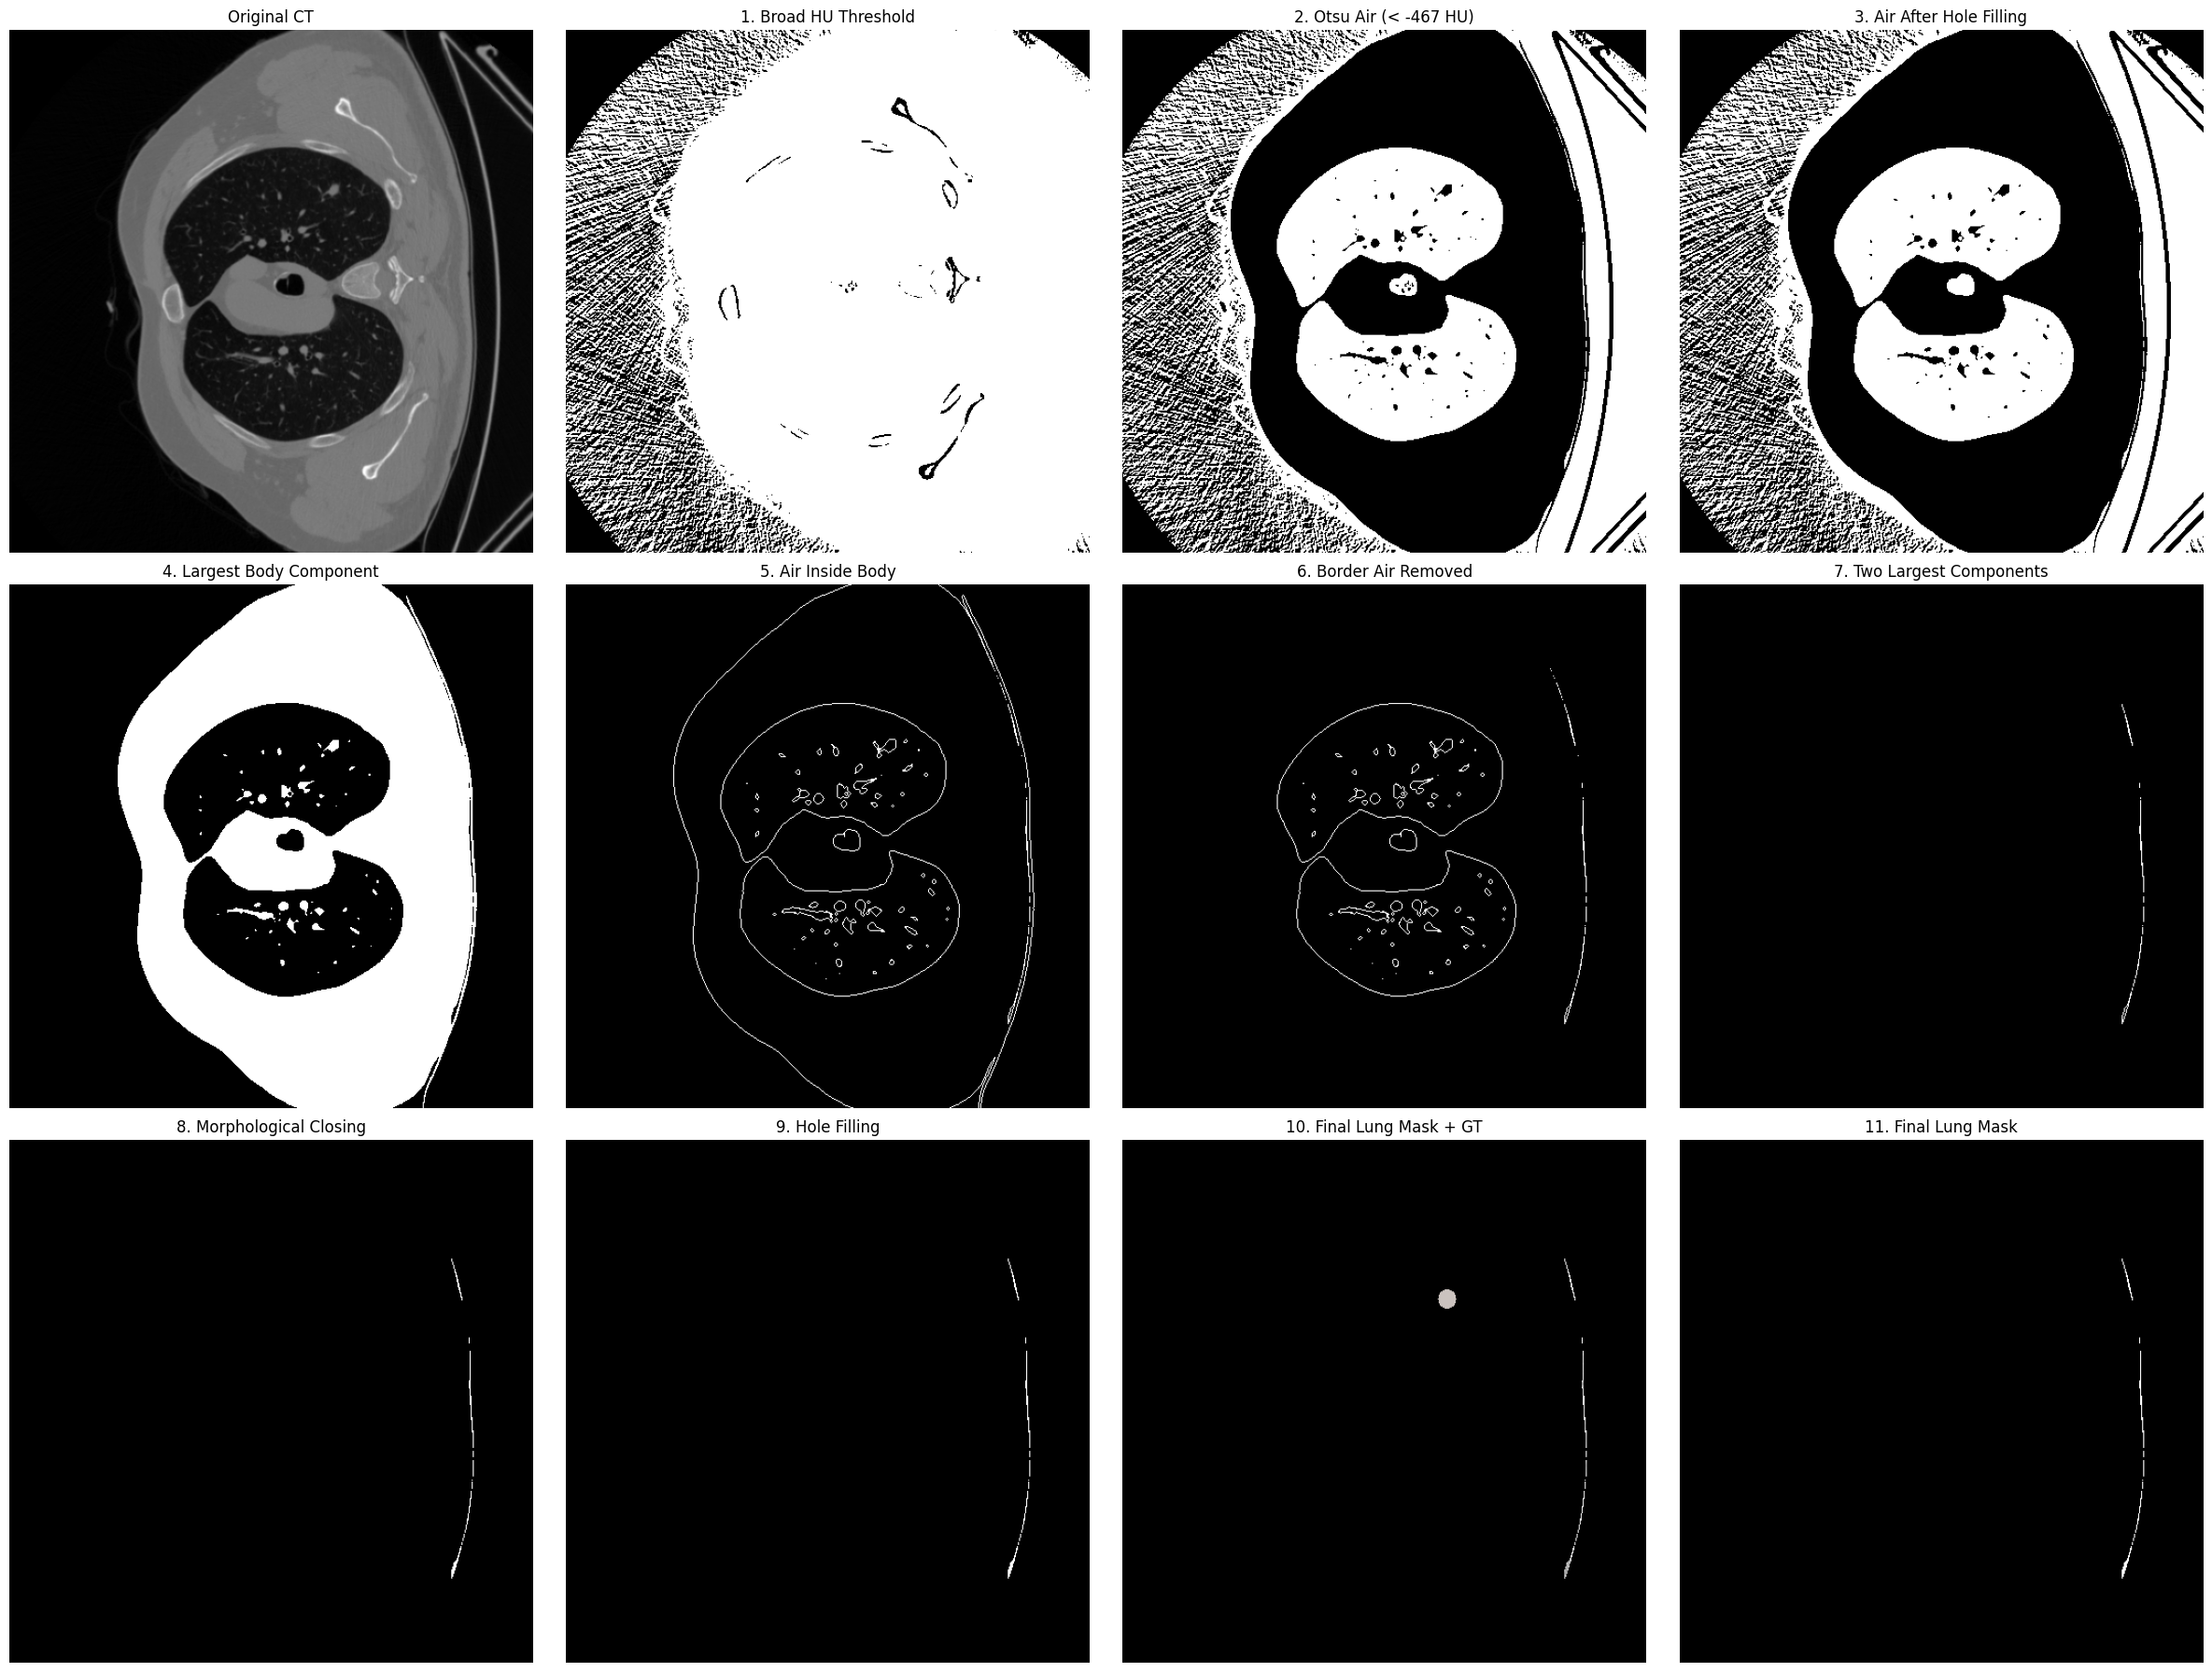


Voxel counts
---------------------------
Broad HU mask      : 101143907
Air mask           : 50267289
Air filled         : 50613839
Body mask          : 50112622
Air inside body    : 1668623
Border removed     : 1122012
Two lungs          : 113987
After closing      : 160362
After hole filling : 160362
Final lungs        : 160362
GT                 : 7253


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.segmentation import clear_border

ct_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_122_b_1.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_122_b_1.nii.gz"

ct = nib.load(ct_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()

# -------------------------------------------------------
# Helper
# -------------------------------------------------------
def keep_largest_components(binary_mask, n=1):
    """
    Keep the n largest connected components.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0

    largest = np.argsort(sizes)[-n:]

    return np.isin(labeled, largest)


# -------------------------------------------------------
# Handle GT dimensions
# -------------------------------------------------------
if gt_mask.ndim == 4:
    gt_mask = gt_mask[0]

print("GT shape:", gt_mask.shape)

slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)


# =======================================================
# Lung preprocessing
# =======================================================

# -------------------------------------------------------
# 1. Broad HU threshold
# -------------------------------------------------------
lung_candidate = (ct >= -1000) & (ct <= 400)


# -------------------------------------------------------
# 2. Otsu threshold
# -------------------------------------------------------
candidate_values = ct[lung_candidate]

otsu_threshold = threshold_otsu(candidate_values)

print(f"Otsu threshold: {otsu_threshold:.1f} HU")

air_mask = lung_candidate & (ct < otsu_threshold)


# -------------------------------------------------------
# 3. Fill holes in air
# -------------------------------------------------------
air_filled = ndimage.binary_fill_holes(air_mask)


# -------------------------------------------------------
# 4. Tissue mask
# -------------------------------------------------------
body_mask = ~air_filled


# -------------------------------------------------------
# 5. Keep largest body component
# -------------------------------------------------------
body_mask = keep_largest_components(body_mask, n=1)


# -------------------------------------------------------
# 6. Restrict air to body
# -------------------------------------------------------
air_inside_body = air_mask & ndimage.binary_dilation(
    body_mask,
    structure=ndimage.generate_binary_structure(3, 1)
)


# -------------------------------------------------------
# 7. Remove border-connected air
# -------------------------------------------------------
mask_clear = np.zeros_like(air_inside_body)

for k in range(air_inside_body.shape[2]):
    mask_clear[:, :, k] = clear_border(air_inside_body[:, :, k])


# -------------------------------------------------------
# 8. Keep two lungs
# -------------------------------------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -------------------------------------------------------
# 9. Morphological closing
# -------------------------------------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -------------------------------------------------------
# 10. Hole filling
# -------------------------------------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -------------------------------------------------------
# 11. Final cleanup
# -------------------------------------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -------------------------------------------------------
# Apply mask
# -------------------------------------------------------
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# =======================================================
# Visualization
# =======================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]

lung_candidate_slice = lung_candidate[:, :, slice_idx]
air_mask_slice = air_mask[:, :, slice_idx]
air_filled_slice = air_filled[:, :, slice_idx]
body_mask_slice = body_mask[:, :, slice_idx]
air_inside_body_slice = air_inside_body[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.ravel()


axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Original CT")
axes[0].axis("off")

axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. Broad HU Threshold")
axes[1].axis("off")

axes[2].imshow(air_mask_slice, cmap="gray")
axes[2].set_title(f"2. Otsu Air (< {otsu_threshold:.0f} HU)")
axes[2].axis("off")

axes[3].imshow(air_filled_slice, cmap="gray")
axes[3].set_title("3. Air After Hole Filling")
axes[3].axis("off")

axes[4].imshow(body_mask_slice, cmap="gray")
axes[4].set_title("4. Largest Body Component")
axes[4].axis("off")

axes[5].imshow(air_inside_body_slice, cmap="gray")
axes[5].set_title("5. Air Inside Body")
axes[5].axis("off")

axes[6].imshow(mask_clear_slice, cmap="gray")
axes[6].set_title("6. Border Air Removed")
axes[6].axis("off")

axes[7].imshow(lungs_only_slice, cmap="gray")
axes[7].set_title("7. Two Largest Components")
axes[7].axis("off")

axes[8].imshow(mask_closed_slice, cmap="gray")
axes[8].set_title("8. Morphological Closing")
axes[8].axis("off")

axes[9].imshow(mask_filled_slice, cmap="gray")
axes[9].set_title("9. Hole Filling")
axes[9].axis("off")

axes[10].imshow(ct_lung_only_slice, cmap="gray")
axes[10].imshow(
    np.ma.masked_where(gt_slice == 0, gt_slice),
    cmap="Reds",
    alpha=0.8
)
axes[10].set_title("10. Final Lung Mask + GT")
axes[10].axis("off")

axes[11].imshow(lungs_final_slice, cmap="gray")
axes[11].set_title("11. Final Lung Mask")
axes[11].axis("off")

plt.tight_layout()
plt.show()


# =======================================================
# Statistics
# =======================================================

print("\nVoxel counts")
print("---------------------------")
print("Broad HU mask      :", lung_candidate.sum())
print("Air mask           :", air_mask.sum())
print("Air filled         :", air_filled.sum())
print("Body mask          :", body_mask.sum())
print("Air inside body    :", air_inside_body.sum())
print("Border removed     :", mask_clear.sum())
print("Two lungs          :", lungs_only.sum())
print("After closing      :", mask_closed.sum())
print("After hole filling :", mask_filled.sum())
print("Final lungs        :", lungs_final.sum())
print("GT                 :", (gt_mask > 0).sum())

In [71]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from totalsegmentator.python_api import totalsegmentator


# ============================================================
# Paths
# ============================================================

ct_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_122_b_1.nii.gz"

output_dir = r"./totalseg_output"

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 1. Run TotalSegmentator
# ============================================================

print("Running TotalSegmentator...")

totalsegmentator(
    input=ct_path,
    output=output_dir,
    task="lung_vessels",
    fast=False
)

print("Segmentation completed")

Running TotalSegmentator...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
  (Using more robust (but slower) 3mm model for cropping.)
Resampling...
  Resampled in 2.54s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 292.47it/s]


  Predicted in 4.65s
Resampling...
  Resampled in 0.45s
  cropping from (512, 512, 319) to (498, 344, 319)
Resampling...
  Resampled in 6.58s
Predicting...


100%|██████████| 90/90 [00:01<00:00, 57.75it/s]


  Predicted in 7.32s
Resampling...
  Resampled in 0.94s
Saving segmentations...
Creating lung_airways_wall.nii.gzCreating lung_arteries.nii.gzCreating lung_veins.nii.gzCreating lung_airways.nii.gz



  Saved in 2.07s
Segmentation completed


In [28]:
from lungmask import LMInferer
import SimpleITK as sitk

inferer = LMInferer()

input_image = sitk.ReadImage("/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7244_a_1.nii.gz")
segmentation = inferer.apply(input_image)

 94%|█████████▍| 16/16.95 [00:00<00:00, 18.91it/s]/home/chest_ct/code/.venv/lib/python3.12/site-packages/tqdm/std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
100%|██████████| 17/16.95 [00:00<-00:00, 19.07it/s]

lungmask 2026-07-13 13:07:54 Postprocessing



100%|██████████| 5/5 [00:00<00:00, 101.55it/s]


Raw GT shape: (3, 512, 512, 339)
GT shape: (339, 512, 512)
CT shape: (339, 512, 512)
Widest slice: 149


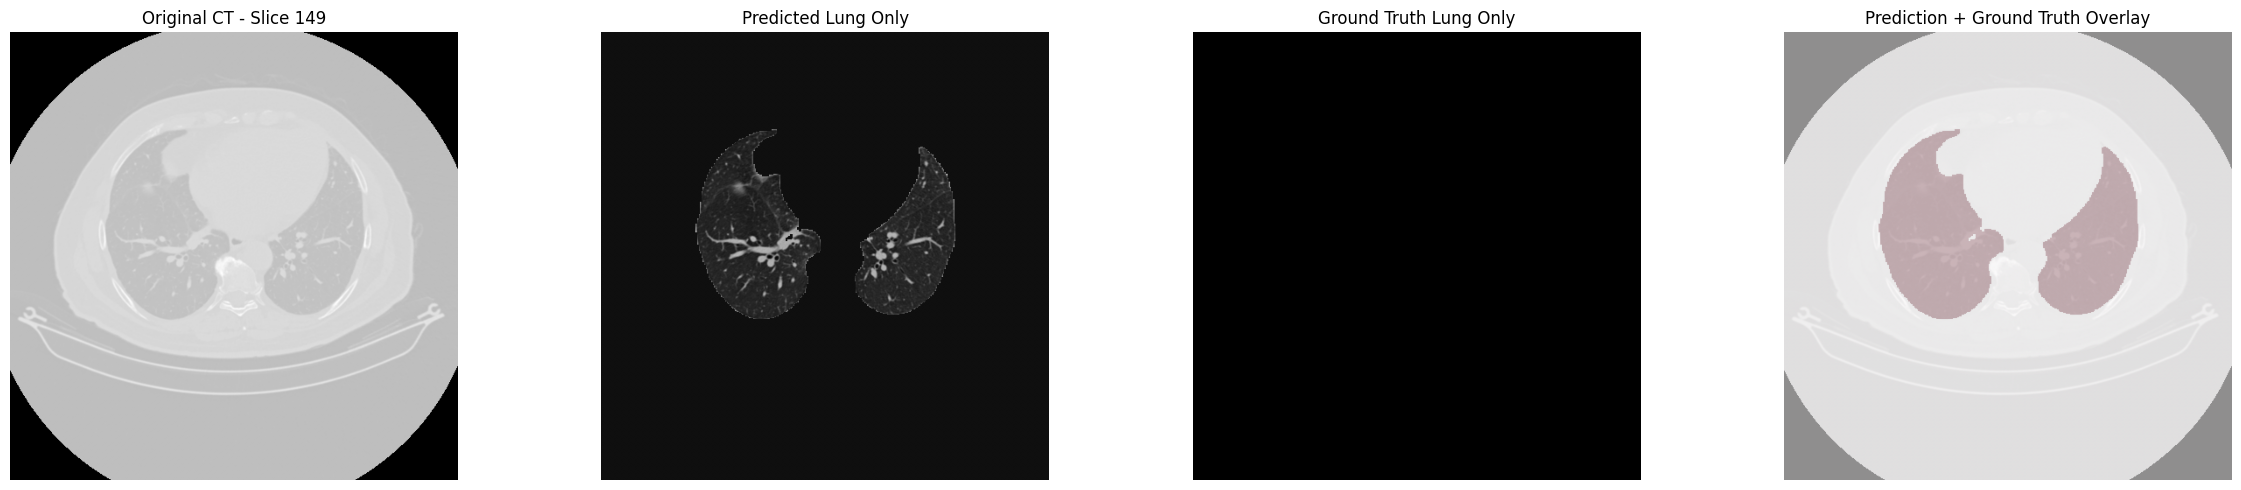

In [30]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk


# ==========================
# Load Ground Truth Mask
# ==========================

mask_path = "/home/chest_ct/code/data/segmentations/segmentations/train_7244_a_1.nii.gz"

gt_raw = nib.load(mask_path).get_fdata()

print("Raw GT shape:", gt_raw.shape)


# Combine GT channels
gt = np.any(gt_raw > 0, axis=0)

# Convert (X,Y,Z) -> (Z,Y,X)
gt = np.transpose(gt, (2,1,0))

print("GT shape:", gt.shape)



# ==========================
# Convert CT
# ==========================

ct = sitk.GetArrayFromImage(input_image)

print("CT shape:", ct.shape)



# ==========================
# Prediction mask
# ==========================

pred = segmentation > 0



# ==========================
# Find widest slice
# ==========================

slice_sizes = pred.sum(axis=(1,2))

slice_idx = np.argmax(slice_sizes)

print("Widest slice:", slice_idx)



# ==========================
# Extract slices
# ==========================

ct_slice = ct[slice_idx]

pred_slice = pred[slice_idx]

gt_slice = gt[slice_idx]



# ==========================
# Apply masks
# ==========================

pred_lung_only = ct_slice.copy()
pred_lung_only[~pred_slice] = -1000


gt_lung_only = ct_slice.copy()
gt_lung_only[~gt_slice] = -1000



# ==========================
# Visualization
# ==========================

plt.figure(figsize=(24,5))


# Original CT

plt.subplot(1,4,1)

plt.imshow(
    ct_slice,
    cmap="gray"
)

plt.title(
    f"Original CT - Slice {slice_idx}"
)

plt.axis("off")



# Predicted Lung Only

plt.subplot(1,4,2)

plt.imshow(
    pred_lung_only,
    cmap="gray"
)

plt.title(
    "Predicted Lung Only"
)

plt.axis("off")



# Ground Truth Lung Only

plt.subplot(1,4,3)

plt.imshow(
    gt_lung_only,
    cmap="gray"
)

plt.title(
    "Ground Truth Lung Only"
)

plt.axis("off")



# Prediction + GT Overlay

plt.subplot(1,4,4)

plt.imshow(
    ct_slice,
    cmap="gray"
)

# predicted mask
plt.imshow(
    pred_slice,
    cmap="Reds",
    alpha=0.35
)

# GT mask
plt.imshow(
    gt_slice,
    cmap="Blues",
    alpha=0.35
)


plt.title(
    "Prediction + Ground Truth Overlay"
)

plt.axis("off")



plt.tight_layout()

plt.show()

In [68]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

mask_path = "/home/chest_ct/code/image-processing/totalseg_output/lung_airways_wall.nii.gz"



# ============================================================
# Load CT and mask
# ============================================================

ct_img = nib.load(ct_path)
ct = ct_img.get_fdata()


mask_img = nib.load(mask_path)
mask = mask_img.get_fdata() > 0



print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)
print("Mask voxels:", mask.sum())



# ============================================================
# Find widest mask slice
# ============================================================

slice_sizes = mask.sum(axis=(0,1))

slice_idx = np.argmax(slice_sizes)


print("Widest mask slice:", slice_idx)
print("Mask pixels on slice:", slice_sizes[slice_idx])



# ============================================================
# Extract slices
# ============================================================

ct_slice = ct[:, :, slice_idx]

mask_slice = mask[:, :, slice_idx]



# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(15,5))


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct_slice,
    cmap="gray"
)

plt.title(
    f"CT - Slice {slice_idx}"
)

plt.axis("off")



# Mask

plt.subplot(1,3,2)

plt.imshow(
    mask_slice,
    cmap="gray"
)

plt.title(
    "Segmentation Mask"
)

plt.axis("off")



# Overlay

plt.subplot(1,3,3)

plt.imshow(
    ct_slice,
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        mask_slice == 0,
        mask_slice
    ),
    cmap="Reds",
    alpha=0.5
)


plt.title(
    f"CT + Mask Overlay\nSlice {slice_idx}"
)

plt.axis("off")



plt.tight_layout()


plt.savefig(
    "mask_overlay_widest_slice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


print("Saved: mask_overlay_widest_slice.png")

CT shape: (512, 512, 319)
Mask shape: (512, 512, 319)
Mask voxels: 280815
Widest mask slice: 166
Mask pixels on slice: 2671
Saved: mask_overlay_widest_slice.png


In [63]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# ============================
# Load lung mask
# ============================

mask_path = "/home/chest_ct/code/image-processing/combined_lung_mask.nii.gz"

lung_mask = nib.load(mask_path).get_fdata() > 0


print("Mask shape:", lung_mask.shape)
print("Lung voxels:", lung_mask.sum())



# ============================
# Find largest lung slice
# ============================

slice_idx = np.argmax(
    lung_mask.sum(axis=(0,1))
)

print("Displaying slice:", slice_idx)



# ============================
# Visualization
# ============================

plt.figure(figsize=(6,6))

plt.imshow(
    lung_mask[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"Combined Lung Mask - Slice {slice_idx}"
)

plt.axis("off")


plt.savefig(
    "combined_lung_mask_view.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


print("Saved: combined_lung_mask_view.png")

Mask shape: (512, 512, 319)
Lung voxels: 13068906
Displaying slice: 141
Saved: combined_lung_mask_view.png


In [61]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


ct = nib.load(
    "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_122_b_1.nii.gz"
).get_fdata()


ts_mask = nib.load(
    "TotalSegmentator_lung_mask.nii.gz"
).get_fdata() > 0



# choose any suspicious slice
slice_idx = 141


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title("Original CT")

plt.axis("off")



plt.subplot(1,3,2)

plt.imshow(
    ts_mask[:,:,slice_idx],
    cmap="gray"
)

plt.title("TotalSegmentator Lung Mask")

plt.axis("off")



plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.imshow(
    np.ma.masked_where(
        ts_mask[:,:,slice_idx]==0,
        ts_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.5
)

plt.title("Lung Boundary Overlay")

plt.axis("off")


plt.tight_layout()
plt.show()

/tmp/ipykernel_448861/2231448259.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [66]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# ============================
# Paths
# ============================

ct_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_122_b_1.nii.gz"

seg_dir = r"./totalseg_output"



# ============================
# Load CT
# ============================

ct_img = nib.load(ct_path)

ct = ct_img.get_fdata()



# ============================
# Combine lung lobe masks
# ============================

lung_files = [
    "lung_upper_lobe_left.nii.gz",
    "lung_lower_lobe_left.nii.gz",
    "lung_upper_lobe_right.nii.gz",
    "lung_middle_lobe_right.nii.gz",
    "lung_lower_lobe_right.nii.gz"
]


# empty mask

lung_mask = np.zeros(
    ct.shape,
    dtype=bool
)


for file in lung_files:

    mask_path = os.path.join(
        seg_dir,
        file
    )

    mask = nib.load(mask_path).get_fdata() > 0

    lung_mask = lung_mask | mask



print("Combined lung voxels:", lung_mask.sum())



# ============================
# Apply lung mask
# ============================

lung_only_ct = ct.copy()

lung_only_ct[
    ~lung_mask
] = -1000



# ============================
# Save combined mask
# ============================

mask_img = nib.Nifti1Image(
    lung_mask.astype(np.uint8),
    ct_img.affine,
    ct_img.header
)


nib.save(
    mask_img,
    "combined_lung_mask.nii.gz"
)



lung_img = nib.Nifti1Image(
    lung_only_ct,
    ct_img.affine,
    ct_img.header
)


nib.save(
    lung_img,
    "lung_only_ct.nii.gz"
)


print("Saved:")
print("combined_lung_mask.nii.gz")
print("lung_only_ct.nii.gz")



# ============================
# Visualization
# ============================

slice_idx = np.argmax(
    lung_mask.sum(axis=(0,1))
)


plt.figure(figsize=(15,5))


# Original

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title("Original CT")

plt.axis("off")



# Mask

plt.subplot(1,3,2)

plt.imshow(
    lung_mask[:,:,slice_idx],
    cmap="gray"
)

plt.title("Combined Lung Mask")

plt.axis("off")



# Overlay

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        lung_mask[:,:,slice_idx]==0,
        lung_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.5
)


plt.title("CT + Lung Mask")

plt.axis("off")


plt.tight_layout()

plt.savefig(
    "lung_mask_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: No such file or no access: 'totalseg_output/lung_upper_lobe_left.nii.gz'

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


import numpy as np
import maxflow

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# ==========================================================
# Step 1: Create initial lung seeds
# ==========================================================

def largest_components(mask, n=2):

    lab = label(mask, connectivity=3)

    sizes = np.bincount(lab.ravel())
    sizes[0] = 0

    keep = np.argsort(sizes)[-n:]

    return np.isin(lab, keep)



# Air seed

air_seed = ct < -750


for z in range(ct.shape[2]):
    air_seed[:,:,z] = clear_border(
        air_seed[:,:,z]
    )


air_seed = largest_components(
    air_seed,
    2
)



# ==========================================================
# Step 2: Create body mask
# ==========================================================

body = ct > -500


body = ndimage.binary_closing(
    body,
    iterations=5
)


body = ndimage.binary_fill_holes(
    body
)



# ==========================================================
# Step 3: Lung probability
# ==========================================================

# Gaussian model of lung intensity

lung_mu = -750
lung_sigma = 250


P_lung = np.exp(
    -0.5 *
    ((ct-lung_mu)/lung_sigma)**2
)



P_lung = np.clip(
    P_lung,
    1e-5,
    1
)



# convert probability to cost

unary_lung = -np.log(P_lung)



# background probability

P_bg = 1-P_lung

unary_bg = -np.log(
    np.clip(
        P_bg,
        1e-5,
        1
    )
)



# ==========================================================
# Step 4: Build Graph
# ==========================================================

shape = ct.shape

N = np.prod(shape)


graph = maxflow.Graph[float]()

nodes = graph.add_nodes(N)



def idx(x,y,z):

    return (
        x*shape[1]*shape[2]
        +
        y*shape[2]
        +
        z
    )



# ==========================================================
# Unary terms
# ==========================================================

flat_ct = ct.ravel()

for i in range(N):

    if not body.ravel()[i]:
        graph.add_tedge(
            i,
            0,
            10000
        )

    else:

        graph.add_tedge(
            i,
            unary_bg.ravel()[i],
            unary_lung.ravel()[i]
        )



# ==========================================================
# Pairwise smoothness
# ==========================================================

smoothness = 5


for x in range(shape[0]-1):

    for y in range(shape[1]-1):

        for z in range(shape[2]-1):

            p = idx(x,y,z)


            neighbors=[
                idx(x+1,y,z),
                idx(x,y+1,z),
                idx(x,y,z+1)
            ]


            for q in neighbors:

                diff = abs(
                    float(
                        ct.ravel()[p]
                        -
                        ct.ravel()[q]
                    )
                )


                weight = (
                    smoothness *
                    np.exp(
                        -diff/50
                    )
                )


                graph.add_edge(
                    p,
                    q,
                    weight,
                    weight
                )



# ==========================================================
# Solve
# ==========================================================

graph.maxflow()


labels = np.zeros(
    N,
    dtype=np.uint8
)


for i in range(N):

    if graph.get_segment(i)==0:
        labels[i]=1



lung_mask = labels.reshape(shape)



# ==========================================================
# Cleanup
# ==========================================================


lung_mask = largest_components(
    lung_mask,
    2
)


lung_mask = ndimage.binary_fill_holes(
    lung_mask
)
lungs_final = lung_mask

print(
    "lung voxels:",
    lung_mask.sum()
)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

KeyboardInterrupt: 

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import (
    clear_border,
    morphological_geodesic_active_contour,
    inverse_gaussian_gradient
)
from skimage.measure import label


# ============================================================
# Helper: keep largest connected components
# ============================================================

def keep_largest_components(mask, n=2):

    labeled, num = label(
        mask,
        return_num=True,
        connectivity=3
    )

    if num == 0:
        return np.zeros_like(mask, dtype=bool)

    sizes = np.bincount(
        labeled.ravel()
    )

    sizes[0] = 0

    largest = np.argsort(sizes)[-n:]

    return np.isin(
        labeled,
        largest
    )



# ============================================================
# Lung segmentation
# ============================================================


# -----------------------------
# 1. Create reliable lung seeds
# -----------------------------
# Very low HU = air inside lung

seed = ct < -700



# Remove outside air slice by slice

seed_clean = np.zeros_like(
    seed,
    dtype=bool
)


for z in range(ct.shape[2]):

    seed_clean[:,:,z] = clear_border(
        seed[:,:,z]
    )



# Keep two lungs

seed_clean = keep_largest_components(
    seed_clean,
    n=2
)



# -----------------------------
# 2. Lung candidate region
# -----------------------------
# Wider range to include abnormalities

candidate = (
    (ct > -950) &
    (ct < -50)
)



# -----------------------------
# 3. 3D region expansion
# -----------------------------

mask = seed_clean.copy()


for i in range(35):

    dilated = ndimage.binary_dilation(
        mask,
        iterations=1
    )

    new_mask = (
        dilated &
        candidate
    )


    if np.array_equal(
        new_mask,
        mask
    ):
        break


    mask = new_mask



# Remove external connections

mask = clear_border(
    mask
)


mask = keep_largest_components(
    mask,
    n=2
)



# -----------------------------
# 4. Active contour refinement
# -----------------------------


# Normalize CT

ct_norm = np.clip(
    ct,
    -1000,
    300
)


ct_norm = (
    ct_norm + 1000
) / 1300



# Smooth

ct_norm = ndimage.gaussian_filter(
    ct_norm,
    sigma=1
)



# Edge image

gimage = inverse_gaussian_gradient(
    ct_norm
)



# Active contour

refined = morphological_geodesic_active_contour(
    gimage,
    60,
    init_level_set=mask.astype(bool),
    smoothing=3,
    balloon=1
)



# -----------------------------
# 5. Final cleanup
# -----------------------------

lungs_final = keep_largest_components(
    refined,
    n=2
)


lungs_final = ndimage.binary_closing(
    lungs_final,
    structure=ndimage.generate_binary_structure(3,2),
    iterations=2
)


lungs_final = ndimage.binary_fill_holes(
    lungs_final
)



# Apply lung mask

ct_lung_only = ct.copy()

ct_lung_only[
    ~lungs_final
] = -1000



# ============================================================
# Visualization
# ============================================================

slice_idx = int(
    np.argmax(
        lungs_final.sum(axis=(0,1))
    )
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,10)
)

axes = axes.ravel()



axes[0].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)
axes[0].set_title("Original CT")


axes[1].imshow(
    seed_clean[:,:,slice_idx],
    cmap="gray"
)
axes[1].set_title("Air Seed")


axes[2].imshow(
    mask[:,:,slice_idx],
    cmap="gray"
)
axes[2].set_title("Region Growing")


axes[3].imshow(
    refined[:,:,slice_idx],
    cmap="gray"
)
axes[3].set_title("Active Contour")


axes[4].imshow(
    lungs_final[:,:,slice_idx],
    cmap="gray"
)
axes[4].set_title("Final Lung Mask")


axes[5].imshow(
    ct_lung_only[:,:,slice_idx],
    cmap="gray"
)
axes[5].set_title("Masked CT")


axes[6].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

axes[6].imshow(
    np.ma.masked_where(
        ~lungs_final[:,:,slice_idx],
        lungs_final[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.4
)

axes[6].set_title(
    "Overlay"
)


axes[7].axis("off")


for ax in axes:
    ax.axis("off")


plt.tight_layout()
plt.show()



# ============================================================
# Statistics
# ============================================================

print("Seed voxels:", seed_clean.sum())
print("Region growing voxels:", mask.sum())
print("Final lung voxels:", lungs_final.sum())

KeyboardInterrupt: 

In [45]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from totalsegmentator.python_api import totalsegmentator


# ============================================================
# 1. Define paths
# ============================================================

ct_path = Path(
    "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1448_c_2.nii.gz"
)

output_dir = Path(
    "/home/chest_ct/code/image-processing/outputs/totalseg_lung"
)
output_dir.mkdir(parents=True, exist_ok=True)

multilabel_seg_path = output_dir / "lung_multilabel.nii.gz"
lung_mask_path = output_dir / "lung_mask.nii.gz"


# ============================================================
# 2. Define lung structures to extract
# ============================================================

lung_lobes = [
    "lung_upper_lobe_left",
    "lung_lower_lobe_left",
    "lung_upper_lobe_right",
    "lung_middle_lobe_right",
    "lung_lower_lobe_right",
]


# ============================================================
# 3. Run TotalSegmentator
# ============================================================

totalsegmentator(
    input=str(ct_path),
    output=str(multilabel_seg_path),
    task="total",
    roi_subset=lung_lobes,
    ml=True,
    fast=True,        # faster inference
    device="cpu",
    quiet=False,
)


print("TotalSegmentator completed")
print("Saved:", multilabel_seg_path)


# ============================================================
# 4. Convert multilabel lung lobes -> binary lung mask
# ============================================================

seg_img = nib.load(str(multilabel_seg_path))
seg = seg_img.get_fdata()


# Any non-zero label belongs to lung
lung_mask = (seg > 0).astype(np.uint8)


lung_mask_img = nib.Nifti1Image(
    lung_mask,
    seg_img.affine,
    seg_img.header
)

nib.save(
    lung_mask_img,
    str(lung_mask_path)
)


print("\nBinary lung mask saved:")
print(lung_mask_path)

print("Lung voxels:", lung_mask.sum())
print("Lung percentage:",
      (lung_mask.sum() / lung_mask.size) * 100)


# ============================================================
# 5. Load CT and visualize largest lung slice
# ============================================================

ct_img = nib.load(str(ct_path))
ct = ct_img.get_fdata()


# Find slice with maximum lung area
slice_idx = np.argmax(
    lung_mask.sum(axis=(0, 1))
)


print("Visualizing slice:", slice_idx)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# Original CT
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(
    f"CT slice {slice_idx}"
)

axes[0].axis("off")


# Overlay mask
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[1].imshow(
    np.ma.masked_where(
        lung_mask[:, :, slice_idx] == 0,
        lung_mask[:, :, slice_idx]
    ),
    cmap="Blues",
    alpha=0.5
)

axes[1].set_title(
    "TotalSegmentator Lung Mask"
)

axes[1].axis("off")


plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'totalsegmentator'

Number of GT voxels: 7253

HU distribution inside GT mask
Min : -903.0
P1  : -864.0
P5  : -837.0
P25 : -765.0
P50 : -616.0
P75 : -232.0
P95 : 32.0
P99 : 55.0
Max : 78.0
Mean: -499.9619467806425
Median: -616.0
Std : 305.4109620077608


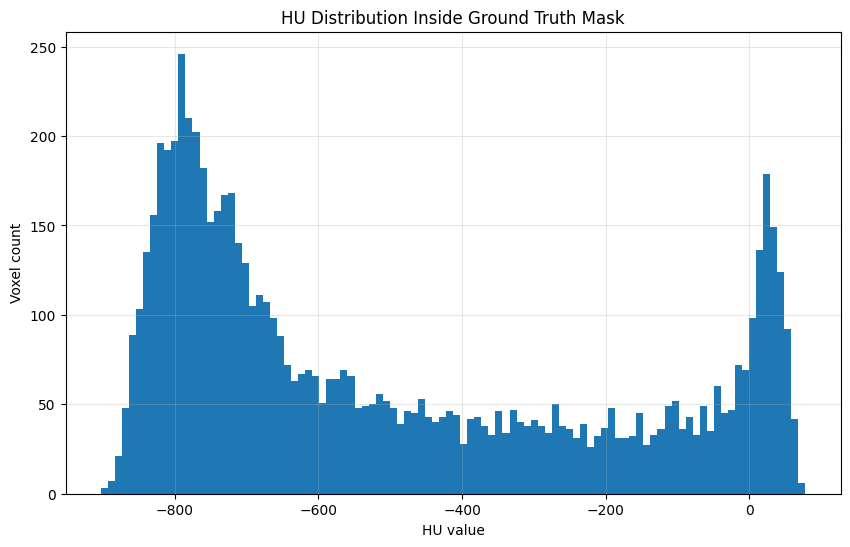

In [4]:
# ============================================================
# HU distribution inside GT mask
# ============================================================

# If GT mask is multi-channel, select one finding/channel
if gt_mask.ndim == 4:
    finding = 0
    gt_mask_single = gt_mask[finding]
else:
    gt_mask_single = gt_mask

# Convert GT to boolean mask
gt_bool = gt_mask_single > 0

# Extract HU values inside GT
gt_hu_values = ct[gt_bool]

# Remove NaN / inf if any
gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

print("Number of GT voxels:", gt_hu_values.size)

if gt_hu_values.size > 0:
    print("\nHU distribution inside GT mask")
    print("Min :", float(np.min(gt_hu_values)))
    print("P1  :", float(np.percentile(gt_hu_values, 1)))
    print("P5  :", float(np.percentile(gt_hu_values, 5)))
    print("P25 :", float(np.percentile(gt_hu_values, 25)))
    print("P50 :", float(np.percentile(gt_hu_values, 50)))  # median
    print("P75 :", float(np.percentile(gt_hu_values, 75)))
    print("P95 :", float(np.percentile(gt_hu_values, 95)))
    print("P99 :", float(np.percentile(gt_hu_values, 99)))
    print("Max :", float(np.max(gt_hu_values)))
    print("Mean:", float(np.mean(gt_hu_values)))
    print("Median:", float(np.median(gt_hu_values)))
    print("Std :", float(np.std(gt_hu_values)))

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(gt_hu_values, bins=100)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside Ground Truth Mask")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("GT mask is empty.")

Selected CTs: 543



Processed: 454
Missing CTs: 70
Missing masks: 19

Missing CT files:
  valid_1001_a_1.nii.gz
  valid_1055_a_1.nii.gz
  valid_1061_a_2.nii.gz
  valid_1077_a_2.nii.gz
  valid_1091_a_1.nii.gz
  valid_1102_a_2.nii.gz
  valid_1103_a_2.nii.gz
  valid_110_a_1.nii.gz
  valid_1113_a_2.nii.gz
  valid_1119_a_1.nii.gz
  valid_1141_a_2.nii.gz
  valid_114_b_2.nii.gz
  valid_1196_a_1.nii.gz
  valid_1213_a_1.nii.gz
  valid_1235_a_2.nii.gz
  valid_1261_a_2.nii.gz
  valid_147_a_2.nii.gz
  valid_189_a_1.nii.gz
  valid_1_a_2.nii.gz
  valid_280_a_2.nii.gz

Missing mask files:
  train_13000_a_2.nii.gz
  train_13011_a_2.nii.gz
  train_13014_a_2.nii.gz
  train_13025_a_2.nii.gz
  train_13043_a_1.nii.gz
  train_13097_b_2.nii.gz
  train_13125_a_2.nii.gz
  train_13218_b_2.nii.gz
  train_13278_c_1.nii.gz
  train_13365_a_2.nii.gz
  train_13380_a_1.nii.gz
  train_13423_a_2.nii.gz
  train_13459_a_2.nii.gz
  train_13484_a_2.nii.gz
  train_13490_a_1.nii.gz
  train_13521_a_1.nii.gz
  train_13593_b_2.nii.gz
  train_13604

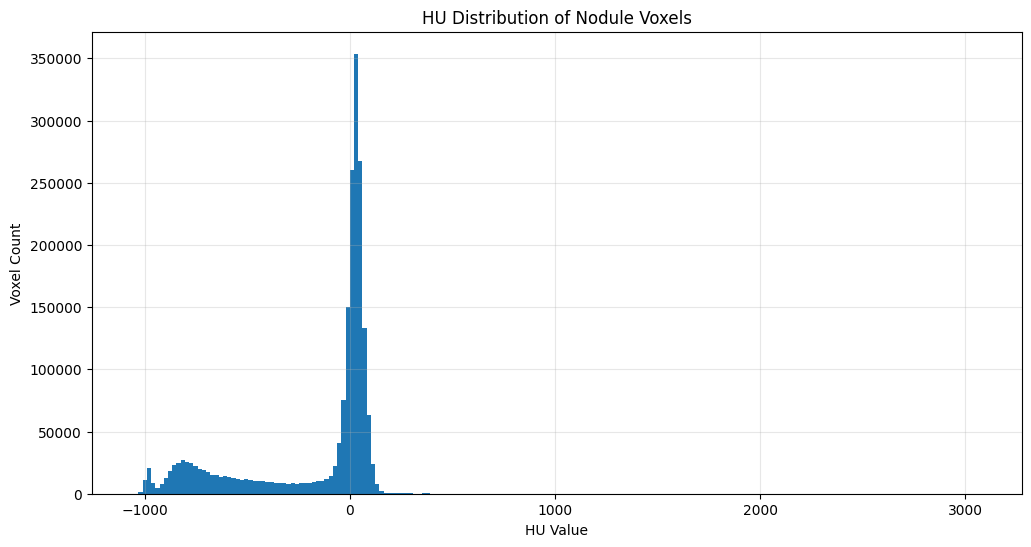

In [4]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# ============================================================
# Narrowest HU ranges containing given percentages of GT values
# ============================================================

def narrowest_hu_range(values, percentages=[1, 5, 10, 15, 50]):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    n = values.size

    if n == 0:
        print("No HU values found.")
        return {}

    results = {}

    for p in percentages:
        # Number of voxels needed to include p%
        window_size = max(1, int(np.ceil((p / 100) * n)))

        # Sliding window over sorted HU values
        starts = values[: n - window_size + 1]
        ends = values[window_size - 1 :]

        widths = ends - starts
        best_idx = int(np.argmin(widths))

        hu_min = float(starts[best_idx])
        hu_max = float(ends[best_idx])
        width = float(hu_max - hu_min)

        results[p] = {
            "min": hu_min,
            "max": hu_max,
            "width": width,
            "voxels": window_size,
        }

        print(f"{p}% HU range:")
        print(f"  Min HU : {hu_min:.2f}")
        print(f"  Max HU : {hu_max:.2f}")
        print(f"  Width  : {width:.2f}")
        print(f"  Voxels : {window_size}")
        print()

    return results


hu_ranges = narrowest_hu_range(gt_hu_values, percentages=[1, 5, 10, 25, 50])

1% HU range:
  Min HU : -832.00
  Max HU : -832.00
  Width  : 0.00
  Voxels : 5

5% HU range:
  Min HU : -823.00
  Max HU : -816.00
  Width  : 7.00
  Voxels : 22

10% HU range:
  Min HU : -832.00
  Max HU : -815.00
  Width  : 17.00
  Voxels : 44

25% HU range:
  Min HU : -841.00
  Max HU : -784.00
  Width  : 57.00
  Voxels : 109

50% HU range:
  Min HU : -845.00
  Max HU : -681.00
  Width  : 164.00
  Voxels : 218



In [6]:
hu_ranges_all = narrowest_hu_range(
    all_hu_values,
    percentages=[1, 5, 10, 25, 50]
)

1% HU range:
  Min HU : -1.00
  Max HU : 0.00
  Width  : 1.00
  Voxels : 20081

5% HU range:
  Min HU : 23.00
  Max HU : 28.00
  Width  : 5.00
  Voxels : 100401

10% HU range:
  Min HU : 21.00
  Max HU : 32.00
  Width  : 11.00
  Voxels : 200801

25% HU range:
  Min HU : 13.00
  Max HU : 43.00
  Width  : 30.00
  Voxels : 502002

50% HU range:
  Min HU : -12.00
  Max HU : 64.00
  Width  : 76.00
  Voxels : 1004004



In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Median:", float(np.median(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

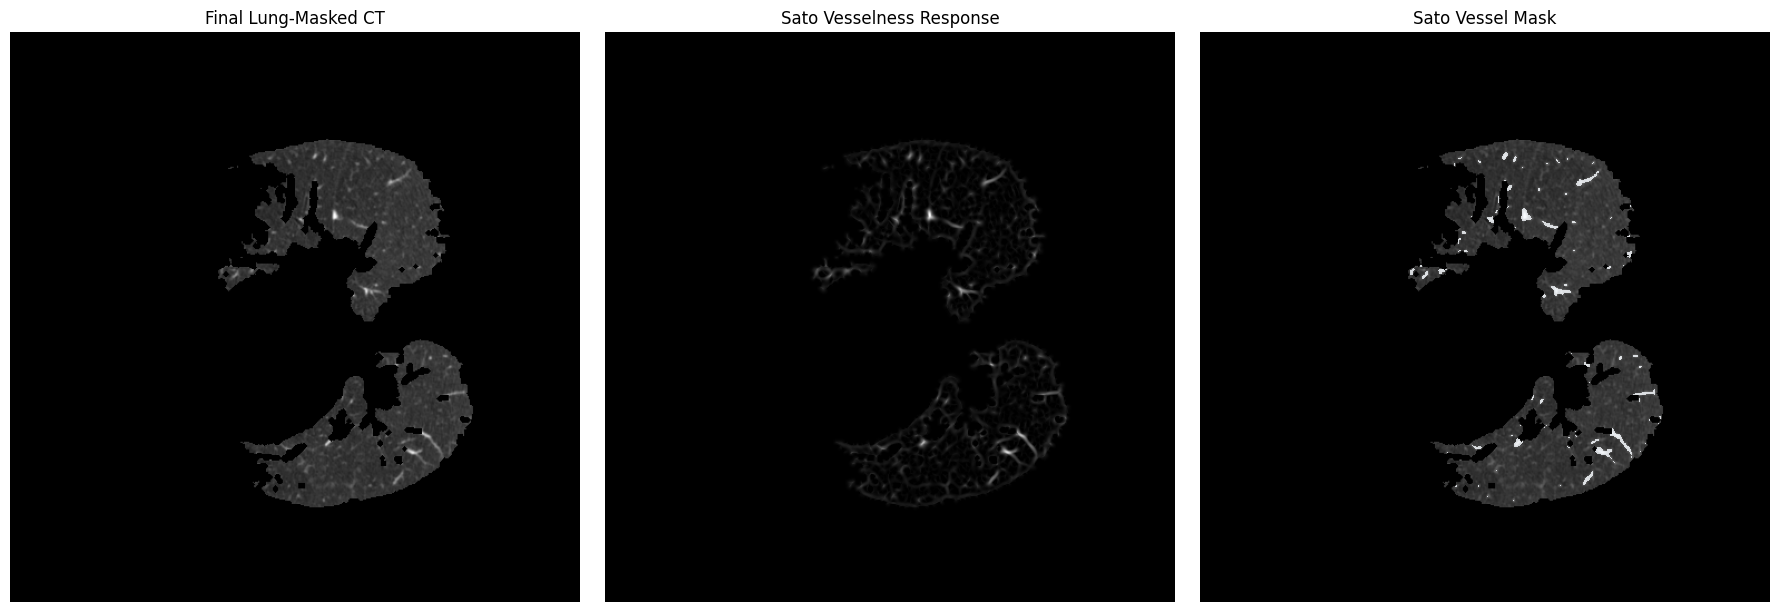

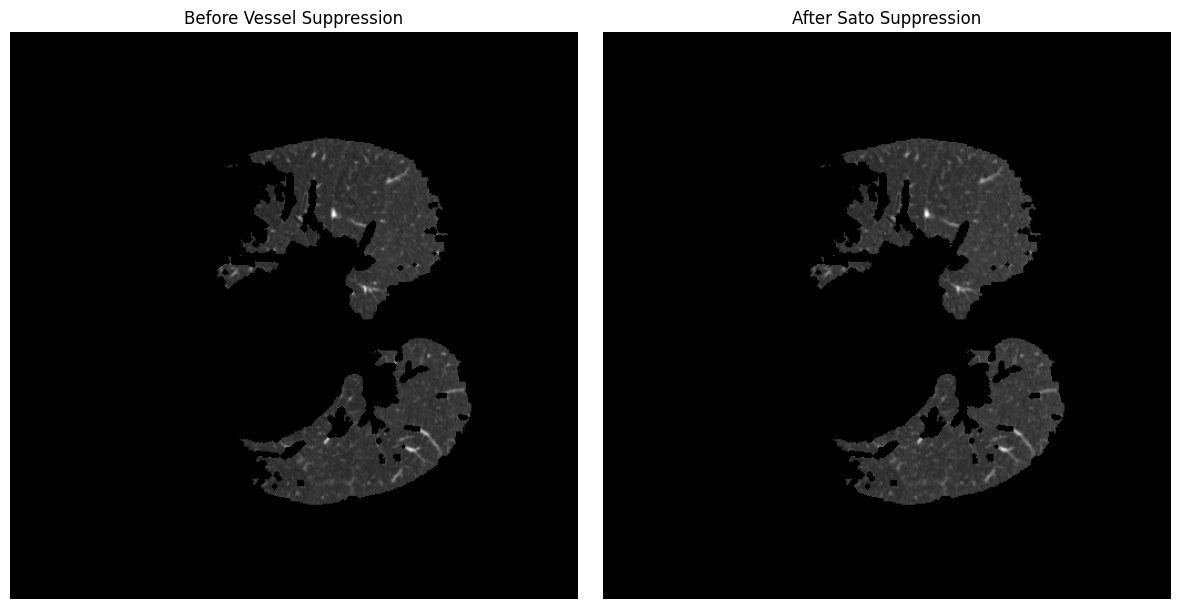

Slice index: 283

Sato vessel candidate pixel count on this slice:
Sato vessel pixels: 902


In [25]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import sato


# ============================================================
# Helper: normalize one CT slice inside lung
# ============================================================
def normalize_lung_slice(ct_slice, lung_slice, hu_min=-900, hu_max=200):
    """
    Clip one CT slice and normalize to [0, 1].
    Outside lung is set to 0.
    """
    ct_clip = np.clip(ct_slice, hu_min, hu_max)
    ct_norm = (ct_clip - hu_min) / (hu_max - hu_min)
    ct_norm[~lung_slice] = 0
    return ct_norm


# ============================================================
# Helper: suppress vessels on one slice only
# ============================================================
def suppress_vessels_from_slice(
    ct_slice,
    vesselness_slice,
    lung_slice,
    percentile=3
):
    """
    Suppress likely vessel pixels on one 2D slice.
    Vessel pixels are replaced by local median values.
    """
    values = vesselness_slice[lung_slice]

    if values.size == 0:
        return ct_slice.copy(), np.zeros_like(lung_slice, dtype=bool)

    threshold = np.percentile(values, percentile)

    vessel_mask = (vesselness_slice >= threshold) & lung_slice

    local_median = ndimage.median_filter(ct_slice, size=3)

    ct_suppressed = ct_slice.copy()
    ct_suppressed[vessel_mask] = local_median[vessel_mask]

    return ct_suppressed, vessel_mask


# ============================================================
# 1. Extract selected slice
# ============================================================
ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]


# ============================================================
# 2. Normalize selected slice for vessel filter
# ============================================================
ct_norm_slice = normalize_lung_slice(
    ct_slice=ct_slice,
    lung_slice=lung_slice,
    hu_min=-900,
    hu_max=200
)


# ============================================================
# 3. Apply Sato vessel filter on 2D slice
# ============================================================
sato_slice = sato(
    ct_norm_slice,
    sigmas=(1, 2),
    black_ridges=False
)


# ============================================================
# 4. Suppress vessel pixels using Sato response
# ============================================================
sato_removed_slice, sato_mask_slice = suppress_vessels_from_slice(
    ct_slice=ct_slice,
    vesselness_slice=sato_slice,
    lung_slice=lung_slice,
    percentile=97
)


# ============================================================
# 5. Visualize CT, Sato response, and vessel mask
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Final Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(sato_slice, cmap="gray")
axes[1].set_title("Sato Vesselness Response")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(~sato_mask_slice, sato_mask_slice),
    cmap="Blues",
    alpha=0.8,
    interpolation="none"
)
axes[2].set_title("Sato Vessel Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Visualize before/after vessel suppression
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Before Vessel Suppression")
axes[0].axis("off")

axes[1].imshow(sato_removed_slice, cmap="gray")
axes[1].set_title("After Sato Suppression")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Print statistics for this slice
# ============================================================
print("Slice index:", slice_idx)
print("\nSato vessel candidate pixel count on this slice:")
print("Sato vessel pixels:", int(sato_mask_slice.sum()))

In [1]:
import numpy as np
from pathlib import Path

npz_path = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz")
data = np.load(npz_path, allow_pickle=True)

print("Arrays stored in the NPZ:\n")
for key in data.files:
    arr = data[key]
    print(f"{key:15s} shape={arr.shape} dtype={arr.dtype}")

Arrays stored in the NPZ:

X               shape=(4096, 56638) dtype=float64
H               shape=(56638,) dtype=int64
scan_ids        shape=(56638,) dtype=object


In [2]:
import numpy as np
from pathlib import Path
from collections import Counter

npz_path = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz")
data = np.load(npz_path, allow_pickle=True)

H = data["H"]

print("Unique labels:", np.unique(H))
print()

print("Patch count per label:")
for label, count in sorted(Counter(H.tolist()).items()):
    print(f"Label {label}: {count} patches")

Unique labels: [0 1 2]

Patch count per label:
Label 0: 18525 patches
Label 1: 34478 patches
Label 2: 3635 patches
